# PREDICTIVE ML MODEL TRAINING FOR HYDRAULIC PRESS THROUGH SYNTHETICALLY GENERATED DATASET

### Set-up & Imports

In [3]:
# 0/ Setup & Imports
import warnings
warnings.filterwarnings('ignore')


import os
import gc
import json
import onnxmltools
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import math

from onnxmltools.convert.common.data_types import FloatTensorType
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.metrics import r2_score
from IPython.display import display
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from scipy.stats import ks_2samp
from pathlib import Path


# Reproducibility
np.random.seed(42)

# Display options for readable, aligned outputs
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

# Small helpers for tidy logs
def print_header(title: str):
    line = '=' * 70
    print(f"\n{line}\n{title}\n{line}")

def print_footer(title: str):
    line = '-' * 70
    print(f"\n{line}\n{title}\n{line}")

def print_kv(pairs):
    # pairs: list of (key, value)
    width = max(len(str(k)) for k, _ in pairs) if pairs else 0
    for k, v in pairs:
        print(f"{str(k).ljust(width)} : {v}")

def R_MSE(y_true, y_pred):
    return np.sqrt(MSE(y_true, y_pred))

def get_numeric_sensor_cols(df: pd.DataFrame, exclude_cols: set) -> list:
    cols = []
    for c in df.columns:
        if c in exclude_cols:
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            cols.append(c)
    return cols

# Create models directory if it doesn't exist
if not os.path.exists("models_and_features"):
    os.makedirs("models_and_features")
    if not os.path.exists("models_and_features/hydraulic_press"):
        os.makedirs("models_and_features/hydraulic_press")
    if not os.path.exists("models_and_features") or not os.path.exists("models_and_features/hydraulic_press"):
        raise RuntimeError("Failed to create models_and_features directory")

save_path= "models_and_features/hydraulic_press/"

print_footer("SETUP AND IMPORTS COMPLETE")



----------------------------------------------------------------------
SETUP AND IMPORTS COMPLETE
----------------------------------------------------------------------


## 1) Dataset Load & Basic Inspection

In [4]:
# 1/ Dataset Load & Basic Inspection

print("1/ DATASET LOAD")

def summarize_df(name, df):
    rows, cols = df.shape
    dtypes = df.dtypes.value_counts()
    dtype_str = ", ".join([f"{dt}: {cnt}" for dt, cnt in dtypes.items()])
    pairs = [
                (f"{name} rows", rows),
                (f"{name} cols", cols),
                (f"{name} dtypes", dtype_str),
            ]
    print("\n".join(f"{k}: {v}" for k, v in pairs))

def ensure_parquet(csv_path):
    parquet_path = csv_path.replace(".csv", ".parquet")
    if not os.path.exists(parquet_path):
        print(f"Converting {csv_path} -> {parquet_path} ...")
        df = pl.read_csv(csv_path)  # Polars CSV reader: streaming + low RAM
        df.write_parquet(parquet_path)
        print("Conversion complete.")
    return parquet_path

# Ensure Parquet versions of datasets exist
long_parquet = ensure_parquet("synthetic_hydraulic_press_data_long_life.csv")
short_parquet = ensure_parquet("synthetic_hydraulic_press_data_short_life.csv")

# Load datasets from Parquet for RAM efficiency
df_long_life = pl.read_parquet(long_parquet)
df_short_life = pl.read_parquet(short_parquet)

print("Long-life dataset:")
print(df_long_life.shape)
print("RUL range:", df_long_life["current_rul"].min(), "-", df_long_life["current_rul"].max())

print("\nShort-life dataset:")
print(df_short_life.shape)
print("RUL range:", df_short_life["current_rul"].min(), "-", df_short_life["current_rul"].max())

print_footer("DATASET LOAD COMPLETE")



1/ DATASET LOAD
Converting synthetic_hydraulic_press_data_long_life.csv -> synthetic_hydraulic_press_data_long_life.parquet ...
Conversion complete.
Converting synthetic_hydraulic_press_data_short_life.csv -> synthetic_hydraulic_press_data_short_life.parquet ...
Conversion complete.
Long-life dataset:
(11425473, 12)
RUL range: 0 - 711434

Short-life dataset:
(150703, 12)
RUL range: 0 - 2988

----------------------------------------------------------------------
DATASET LOAD COMPLETE
----------------------------------------------------------------------


In [5]:
# 1A/ Long-Life Dataset Summary
print_header("1A/ LONG-LIFE DATASET SUMMARY")

df_raw_long_life = df_long_life.clone()

rows, cols = df_raw_long_life.shape
dtypes = df_raw_long_life.dtypes
dtype_counts = {}
for dt in dtypes:
    dtype_counts[str(dt)] = dtype_counts.get(str(dt), 0) + 1
dtype_str = ", ".join([f"{k}: {v}" for k, v in dtype_counts.items()])

print(f"Merged DataFrame rows: {rows}")
print(f"Merged DataFrame cols: {cols}")
print(f"Merged DataFrame dtypes: {dtype_str}")

print("-" * 40)
print("\nColumns:")
print(df_raw_long_life.columns)
print("-" * 40)

print("\nDescription:")
print(df_raw_long_life.describe())
print("-" * 40)

print("\nNull Values:")
null_values = df_raw_long_life.null_count().to_series().sum()
print(f"NULL Total: {null_values}")
print("-" * 40)

print("\nDuplicate Rows:")
duplicate_rows = df_raw_long_life.is_duplicated().sum()
print(f"Duplicate Total: {duplicate_rows}")
print("-" * 40)

print("\nUnique Values:")
unique_values = df_raw_long_life.n_unique()
print(f"Unique Total: {unique_values}")
print("-" * 40)

start_date = pl.datetime(2026, 1, 1)
df_raw_long_life = df_raw_long_life.with_columns(
                                                    (start_date + pl.duration(minutes=pl.col("time_min"))).alias("timestamp")
                                                )

timestamp_diffs = df_raw_long_life["timestamp"].diff().drop_nulls()
timestamp_diffs_seconds = timestamp_diffs.dt.total_seconds()

print("\nFirst 10 timestamp differences seconds:")
print(timestamp_diffs_seconds.head(10))
print(f"Average increase seconds: {timestamp_diffs_seconds.mean():.1f}")
print(f"Average increase minutes: {timestamp_diffs_seconds.mean() / 60:.2f}")
print("-" * 40)

rul_min = df_raw_long_life["current_rul"].min()
rul_max = df_raw_long_life["current_rul"].max()

print(f"\nRUL Min Max time minutes: {rul_min} {rul_max:.2f} minutes")
print(f"RUL Min Max time hours: {rul_min / 60} {rul_max / 60:.2f} hours")

print("\nRow count per cycle:")
print(df_raw_long_life["cycle_id"].value_counts().sort("cycle_id"))

print("\nTotal RUL distribution:")
print(df_raw_long_life["total_rul"].value_counts())

print_footer("LONG-LIFE DATASET SUMMARY COMPLETE")


1A/ LONG-LIFE DATASET SUMMARY
Merged DataFrame rows: 11425473
Merged DataFrame cols: 12
Merged DataFrame dtypes: Int64: 4, Float64: 8
----------------------------------------

Columns:
['cycle_id', 'time_min', 'total_rul', 'current_rul', 'hydraulic_pressure', 'oil_temperature', 'oil_contamination', 'ram_position_deviation', 'press_force', 'vibration', 'flow_rate', 'motor_current']
----------------------------------------

Description:
shape: (9, 13)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ cycle_id  ┆ time_min  ┆ total_rul ┆ … ┆ press_for ┆ vibration ┆ flow_rate ┆ motor_cu │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ce        ┆ ---       ┆ ---       ┆ rrent    │
│ str       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ ---       ┆ f64       ┆ f64       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆           ┆           ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══

In [6]:
# 1B/ Short-Life Dataset Summary
print_header("1B/ SHORT-LIFE DATASET SUMMARY")

df_raw_short_life = df_short_life.clone()

rows, cols = df_raw_short_life.shape
dtypes = df_raw_short_life.dtypes
dtype_counts = {}
for dt in dtypes:
    dtype_counts[str(dt)] = dtype_counts.get(str(dt), 0) + 1
dtype_str = ", ".join([f"{k}: {v}" for k, v in dtype_counts.items()])

print(f"Merged DataFrame rows: {rows}")
print(f"Merged DataFrame cols: {cols}")
print(f"Merged DataFrame dtypes: {dtype_str}")

print("-" * 40)
print("\nColumns:")
print(df_raw_short_life.columns)
print("-" * 40)

print("\nDescription:")
print(df_raw_short_life.describe())
print("-" * 40)

print("\nNull Values:")
null_values = df_raw_short_life.null_count().to_series().sum()
print(f"NULL Total: {null_values}")
print("-" * 40)

print("\nDuplicate Rows:")
duplicate_rows = df_raw_short_life.is_duplicated().sum()
print(f"Duplicate Total: {duplicate_rows}")
print("-" * 40)

print("\nUnique Values:")
unique_values = df_raw_short_life.n_unique()
print(f"Unique Total: {unique_values}")
print("-" * 40)

start_date = pl.datetime(2026, 1, 1)
df_raw_short_life = df_raw_short_life.with_columns(
    (start_date + pl.duration(minutes=pl.col("time_min"))).alias("timestamp")
)

timestamp_diffs = df_raw_short_life["timestamp"].diff().drop_nulls()
timestamp_diffs_seconds = timestamp_diffs.dt.total_seconds()

print("\nFirst 10 timestamp differences seconds:")
print(timestamp_diffs_seconds.head(10))
print(f"Average increase seconds: {timestamp_diffs_seconds.mean():.1f}")
print(f"Average increase minutes: {timestamp_diffs_seconds.mean() / 60:.2f}")
print("-" * 40)

rul_min = df_raw_short_life["current_rul"].min()
rul_max = df_raw_short_life["current_rul"].max()

print(f"\nRUL Min Max time minutes: {rul_min} {rul_max:.2f} minutes")
print(f"RUL Min Max time hours: {rul_min / 60} {rul_max / 60:.2f} hours")

print("\nRow count per cycle:")
print(df_raw_short_life["cycle_id"].value_counts().sort("cycle_id"))

print("\nTotal RUL distribution:")
print(df_raw_short_life["total_rul"].value_counts())

print_footer("SHORT-LIFE DATASET SUMMARY COMPLETE")


1B/ SHORT-LIFE DATASET SUMMARY
Merged DataFrame rows: 150703
Merged DataFrame cols: 12
Merged DataFrame dtypes: Int64: 4, Float64: 8
----------------------------------------

Columns:
['cycle_id', 'time_min', 'total_rul', 'current_rul', 'hydraulic_pressure', 'oil_temperature', 'oil_contamination', 'ram_position_deviation', 'press_force', 'vibration', 'flow_rate', 'motor_current']
----------------------------------------

Description:
shape: (9, 13)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ cycle_id  ┆ time_min  ┆ total_rul ┆ … ┆ press_for ┆ vibration ┆ flow_rate ┆ motor_cu │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ce        ┆ ---       ┆ ---       ┆ rrent    │
│ str       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ ---       ┆ f64       ┆ f64       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆           ┆           ┆ f64      │
╞═══════════╪═══════════╪═══════════╪════

## 2) Explanatory Data Analysis (EDA)

2/ EXPLORATORY DATA ANALYSIS - Compact sensor overview (overlayed cycles)
Selected cycles to plot (Short Life): [1, 23, 31, 32]


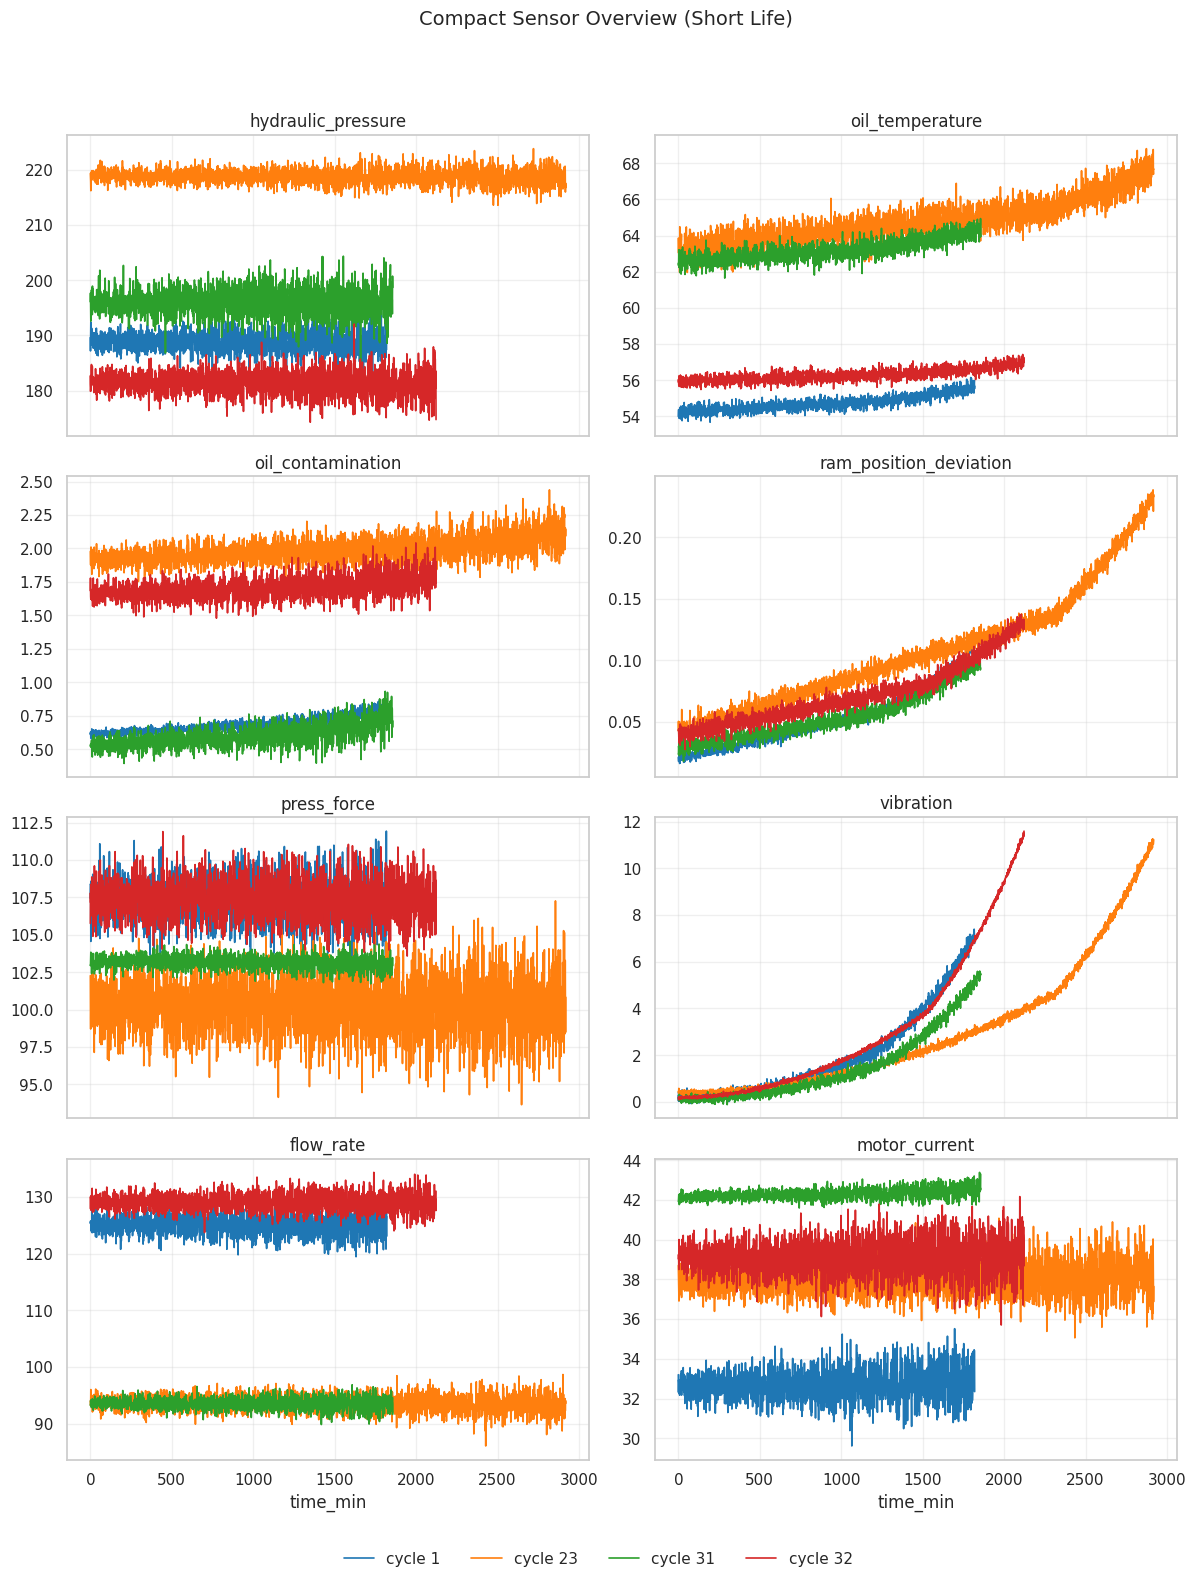

Selected cycles to plot (Long Life): [16, 18, 24, 28]


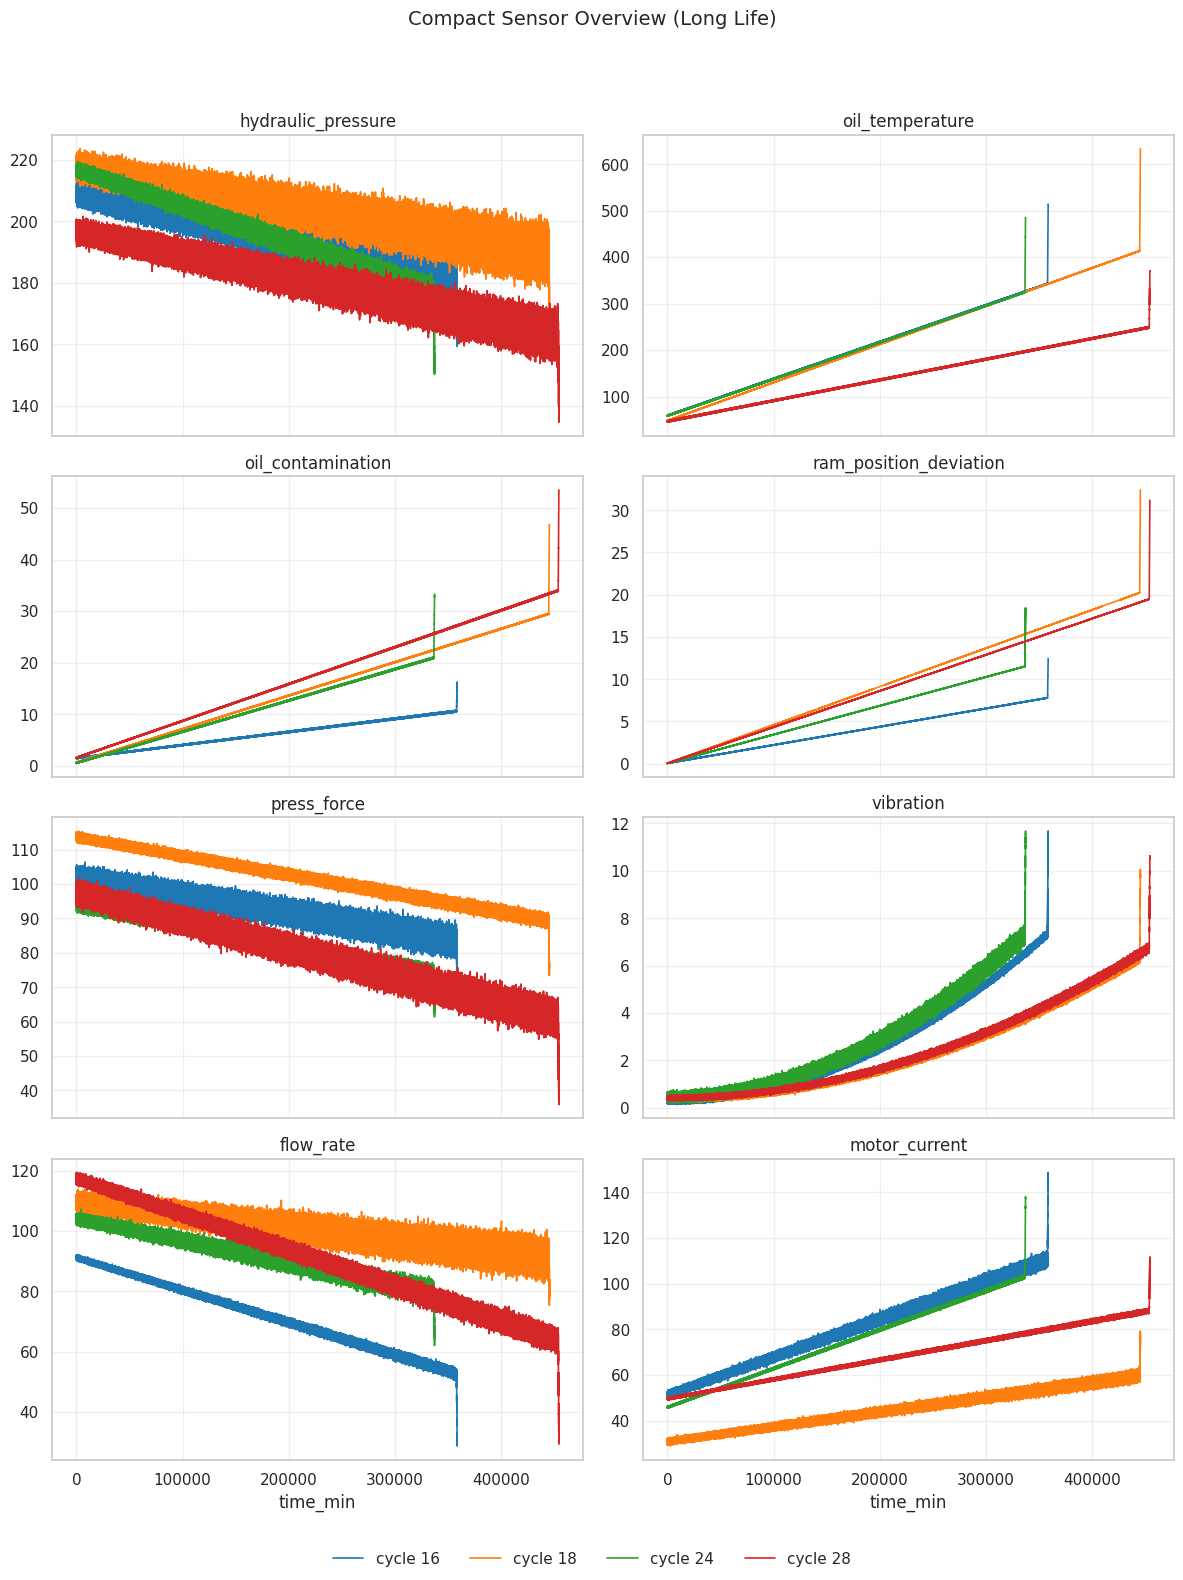

In [7]:
# 2/ Exploratory Data Analysis - Compact sensor overview (overlayed cycles)
print("2/ EXPLORATORY DATA ANALYSIS - Compact sensor overview (overlayed cycles)")
# ensure daasets are loaded
assert 'df_raw_short_life' in globals() and 'df_raw_long_life' in globals(), "Datasets must be defined (run dataset load cells)"

def plot_compact_cycles(dataframe_input, title_suffix=""):
    # Convert to Polars if input is Pandas to ensure memory efficiency and compatibility
    if not isinstance(dataframe_input, pl.DataFrame):
        dataframe_polars = pl.from_pandas(dataframe_input)
    else:
        dataframe_polars = dataframe_input

    sensor_cols = ["hydraulic_pressure", "oil_temperature", "oil_contamination",
                   "ram_position_deviation", "press_force", "vibration",
                   "flow_rate", "motor_current"]
    # verify all sensor present
    missing_columns = [column_name for column_name in sensor_cols if column_name not in dataframe_polars.columns]
    if missing_columns:
        print(f"Warning: missing columns: {missing_columns}")
        sensor_cols = [column_name for column_name in sensor_cols if column_name in dataframe_polars.columns]

    if len(sensor_cols) == 0:
        print("No sensor columns available to plot.")
        return
    # Select a few cycles to compare 
    np.random.seed(42)
    unique_cycle_ids = sorted(dataframe_polars.get_column("cycle_id").unique().to_list())
    number_of_plots = min(4, len(unique_cycle_ids))
    if number_of_plots == 0:
        print("No cycles available to plot")
        return
    
    selected_cycle_ids = sorted(np.random.choice(unique_cycle_ids, size=number_of_plots, replace=False))
    print(f"Selected cycles to plot {title_suffix}: {selected_cycle_ids}")
    # Set up the plotting style
    try:
        sns.set_theme(style='whitegrid')
    except Exception:
        try:
            sns.set_style('whitegrid')
        except Exception:
            if 'whitegrid' in plt.style.available:
                plt.style.use('whitegrid')
            else:
                plt.style.use('default')

    number_of_sensors = len(sensor_cols)
    plot_columns_count = 2
    plot_rows_count = math.ceil(number_of_sensors / plot_columns_count)

    fig, axes = plt.subplots(plot_rows_count, plot_columns_count, figsize=(12, 4 * plot_rows_count), sharex=True)
    axes = np.array(axes).reshape(-1)
    # color palette with fallback
    try:
        plot_colors = sns.color_palette('tab10', number_of_plots)
    except Exception:
        plot_colors = list(plt.cm.get_cmap('tab10').colors)[:number_of_plots]

    for sensor_index, sensor_name in enumerate(sensor_cols):
        current_axis = axes[sensor_index]
        for cycle_index, cycle_id in enumerate(selected_cycle_ids):
            cycle_subset = dataframe_polars.filter(pl.col("cycle_id") == cycle_id).sort("time_min")
            if sensor_name in cycle_subset.columns:
                current_axis.plot(
                                    cycle_subset.get_column("time_min").to_numpy(), 
                                    cycle_subset.get_column(sensor_name).to_numpy(), 
                                    label=f'cycle {cycle_id}', 
                                    color=plot_colors[cycle_index], 
                                    linewidth=1.2
                                )
        current_axis.set_title(sensor_name)
        current_axis.grid(alpha=0.3)
    
    for unused_index in range(number_of_sensors, len(axes)):
        axes[unused_index].axis('off')

    bottom_row_axes = axes[(plot_rows_count - 1) * plot_columns_count : plot_rows_count * plot_columns_count]
    for bottom_axis in bottom_row_axes:
        bottom_axis.set_xlabel('time_min')

    legend_handles, legend_labels = axes[0].get_legend_handles_labels()
    if legend_handles:
        fig.legend(legend_handles, legend_labels, loc='lower center', ncol=number_of_plots, frameon=False)

    fig.suptitle(f"Compact Sensor Overview {title_suffix}", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

plot_compact_cycles(df_raw_short_life, title_suffix="(Short Life)")
plot_compact_cycles(df_raw_long_life, title_suffix="(Long Life)")

### 2A) Additional EDA: RUL, Correlation & Distributions

2A/ ADDITIONAL EDA - RUL time-series, sensor correlations, and boxplots
Short-Life Dataset Analysis


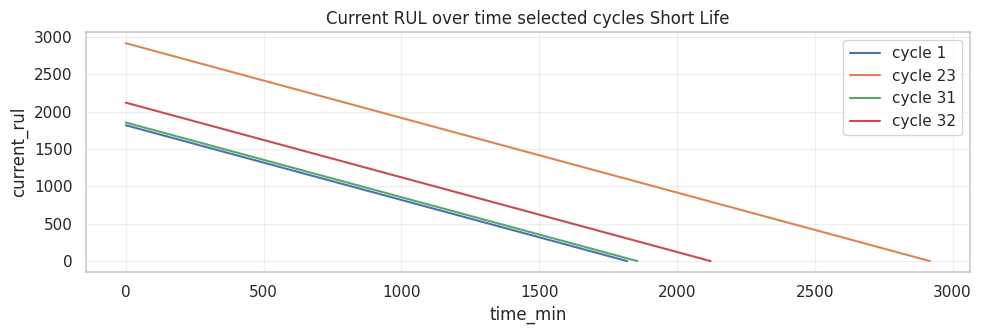

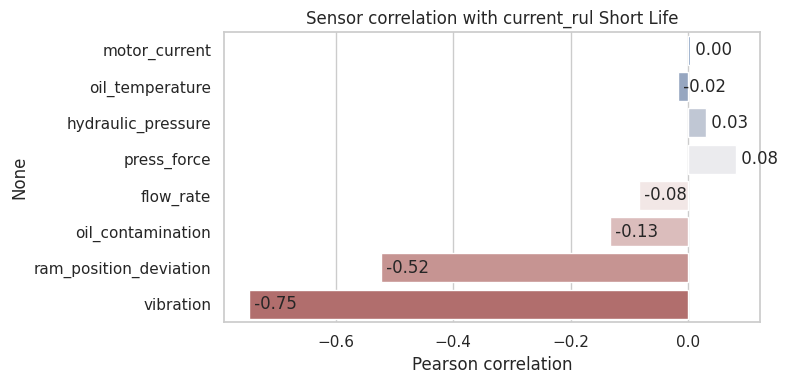

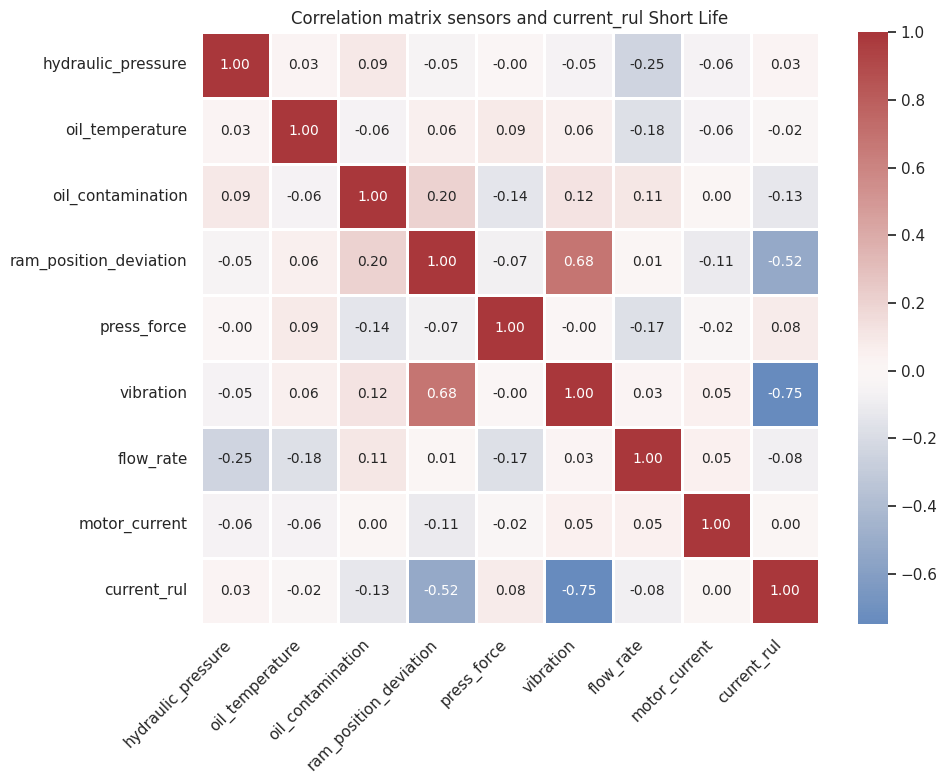

Long-Life Dataset Analysis


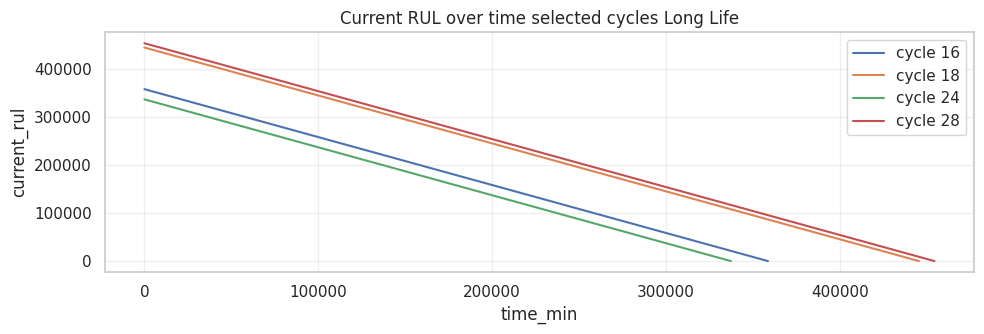

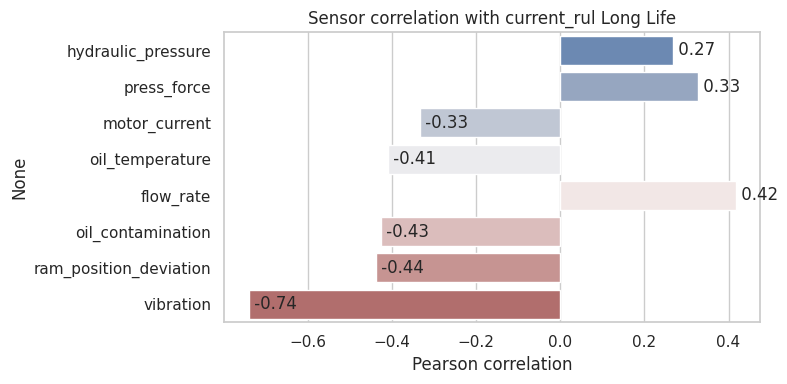

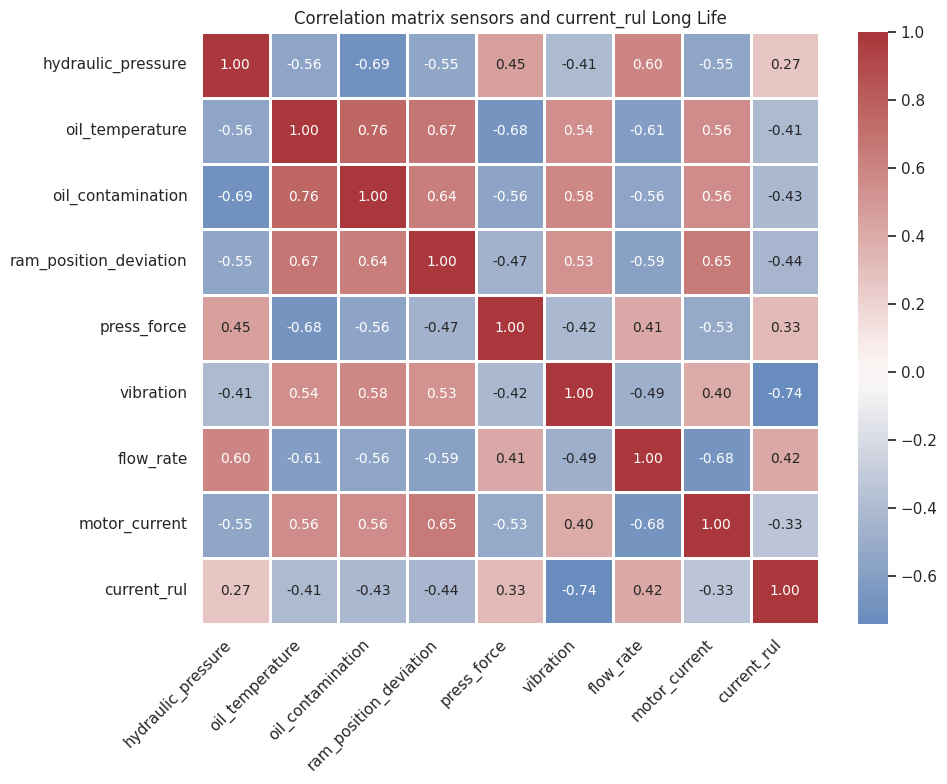

In [8]:
# 2A/ Additional EDA
print("2A/ ADDITIONAL EDA - RUL time-series, sensor correlations, and boxplots")

assert 'df_raw_short_life' in globals() and 'df_raw_long_life' in globals(), "Datasets must be defined"

def additional_eda(dataframe_input, title_suffix=""):
    if not isinstance(dataframe_input, pl.DataFrame):
        dataframe_polars = pl.from_pandas(dataframe_input)
    else:
        dataframe_polars = dataframe_input

    sensors = [
                "hydraulic_pressure", "oil_temperature", "oil_contamination",
                "ram_position_deviation", "press_force", "vibration",
                "flow_rate", "motor_current"
            ]
    available_sensors = [sensor_name for sensor_name in sensors if sensor_name in dataframe_polars.columns]

    if not available_sensors:
        print(f"No sensor columns available for 2A EDA {title_suffix}")
        return

    np.random.seed(42)
    unique_cycle_ids = sorted(dataframe_polars.get_column("cycle_id").unique().to_list())
    number_of_cycles = min(4, len(unique_cycle_ids))
    selected_cycle_ids = sorted(np.random.choice(unique_cycle_ids, size=number_of_cycles, replace=False))

    plt.figure(figsize=(10, 3.5))
    for cycle_id in selected_cycle_ids:
        cycle_subset = dataframe_polars.filter(pl.col("cycle_id") == cycle_id).sort("time_min")
        plt.plot(
                    cycle_subset.get_column("time_min").to_numpy(),
                    cycle_subset.get_column("current_rul").to_numpy(),
                    label=f'cycle {cycle_id}',
                    linewidth=1.5
                )
    plt.xlabel('time_min')
    plt.ylabel('current_rul')
    plt.title(f'Current RUL over time selected cycles {title_suffix}')
    plt.grid(alpha=0.3)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    if 'current_rul' in dataframe_polars.columns:
        correlation_columns = available_sensors + ['current_rul']

        # compute correlation in polars
        corr_polars = dataframe_polars.select(correlation_columns).corr()

        # convert to pandas
        corr_pd = corr_polars.to_pandas()

        # rename rows and columns to sensor names
        corr_pd.index = correlation_columns
        corr_pd.columns = correlation_columns

        # extract correlations with current_rul
        rul_corr = corr_pd["current_rul"].drop("current_rul")

        # sort by absolute value
        rul_corr_sorted = rul_corr.reindex(rul_corr.abs().sort_values().index)

        plt.figure(figsize=(8, 4))
        sns.barplot(
                        x=rul_corr_sorted.values,
                        y=rul_corr_sorted.index,
                        palette='vlag'
                    )
        plt.xlabel('Pearson correlation')
        plt.title(f'Sensor correlation with current_rul {title_suffix}')
        for index_pos, correlation_value in enumerate(rul_corr_sorted.values):
            plt.text(correlation_value, index_pos, f" {correlation_value:.2f}", va='center')
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 8))
        sns.heatmap(
                        corr_pd.loc[correlation_columns, correlation_columns],
                        annot=True,
                        fmt='.2f',
                        cmap='vlag',
                        center=0,
                        annot_kws={"size": 10},
                        linewidths=1
                    )
        plt.title(f'Correlation matrix sensors and current_rul {title_suffix}', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()


print("Short-Life Dataset Analysis")
additional_eda(df_raw_short_life, title_suffix="Short Life")

print("Long-Life Dataset Analysis")
additional_eda(df_raw_long_life, title_suffix="Long Life")

### 2B) Cycle-to-cycle comparison (start vs end)

2B/ CYCLE COMPARISONS - start vs end summaries and plots
Comparing sensors (Short Life): ['hydraulic_pressure', 'oil_temperature', 'oil_contamination', 'ram_position_deviation', 'press_force', 'vibration', 'flow_rate', 'motor_current']

Example start/end table (Short Life) (first 8 cycles - sample sensors):


,cycle_id,hydraulic_pressure,oil_temperature,oil_contamination,ram_position_deviation,hydraulic_pressure_end,oil_temperature_end,oil_contamination_end,ram_position_deviation_end
0,1,189.631,54.002,0.620,0.021,189.511,55.673,0.848,0.110
1,2,219.337,64.685,1.810,0.016,217.611,66.927,1.929,0.076
2,3,210.147,49.772,1.775,0.035,207.679,52.359,1.865,0.139
3,4,207.230,54.396,1.207,0.034,210.229,55.260,1.458,0.102
4,5,207.566,55.365,1.723,0.013,206.884,57.861,1.778,0.110
5,6,192.565,62.080,1.104,0.033,188.404,64.464,1.186,0.088
6,7,183.618,53.499,1.530,0.048,182.958,57.288,1.873,0.151
7,8,222.267,61.919,1.453,0.007,214.192,62.817,1.559,0.114



Delta summary (Short Life) (end - start):
                              count   mean    std    min    25%    50%    75%     max
hydraulic_pressure_delta       80.0 -0.523  3.323 -8.075 -2.860 -0.595  2.101   8.591
oil_temperature_delta          80.0  1.928  0.969 -0.017  1.318  1.701  2.502   4.388
oil_contamination_delta        80.0  0.155  0.106 -0.083  0.092  0.156  0.220   0.490
ram_position_deviation_delta   80.0  0.082  0.041  0.015  0.051  0.073  0.100   0.226
press_force_delta              80.0 -0.430  1.849 -5.301 -1.460 -0.576  0.547   3.789
vibration_delta                80.0  8.287  2.217  4.458  6.241  8.894  9.874  12.315
flow_rate_delta                80.0 -0.225  1.868 -5.167 -1.542 -0.377  0.994   5.261
motor_current_delta            80.0  0.540  0.824 -1.384  0.043  0.491  0.906   3.033


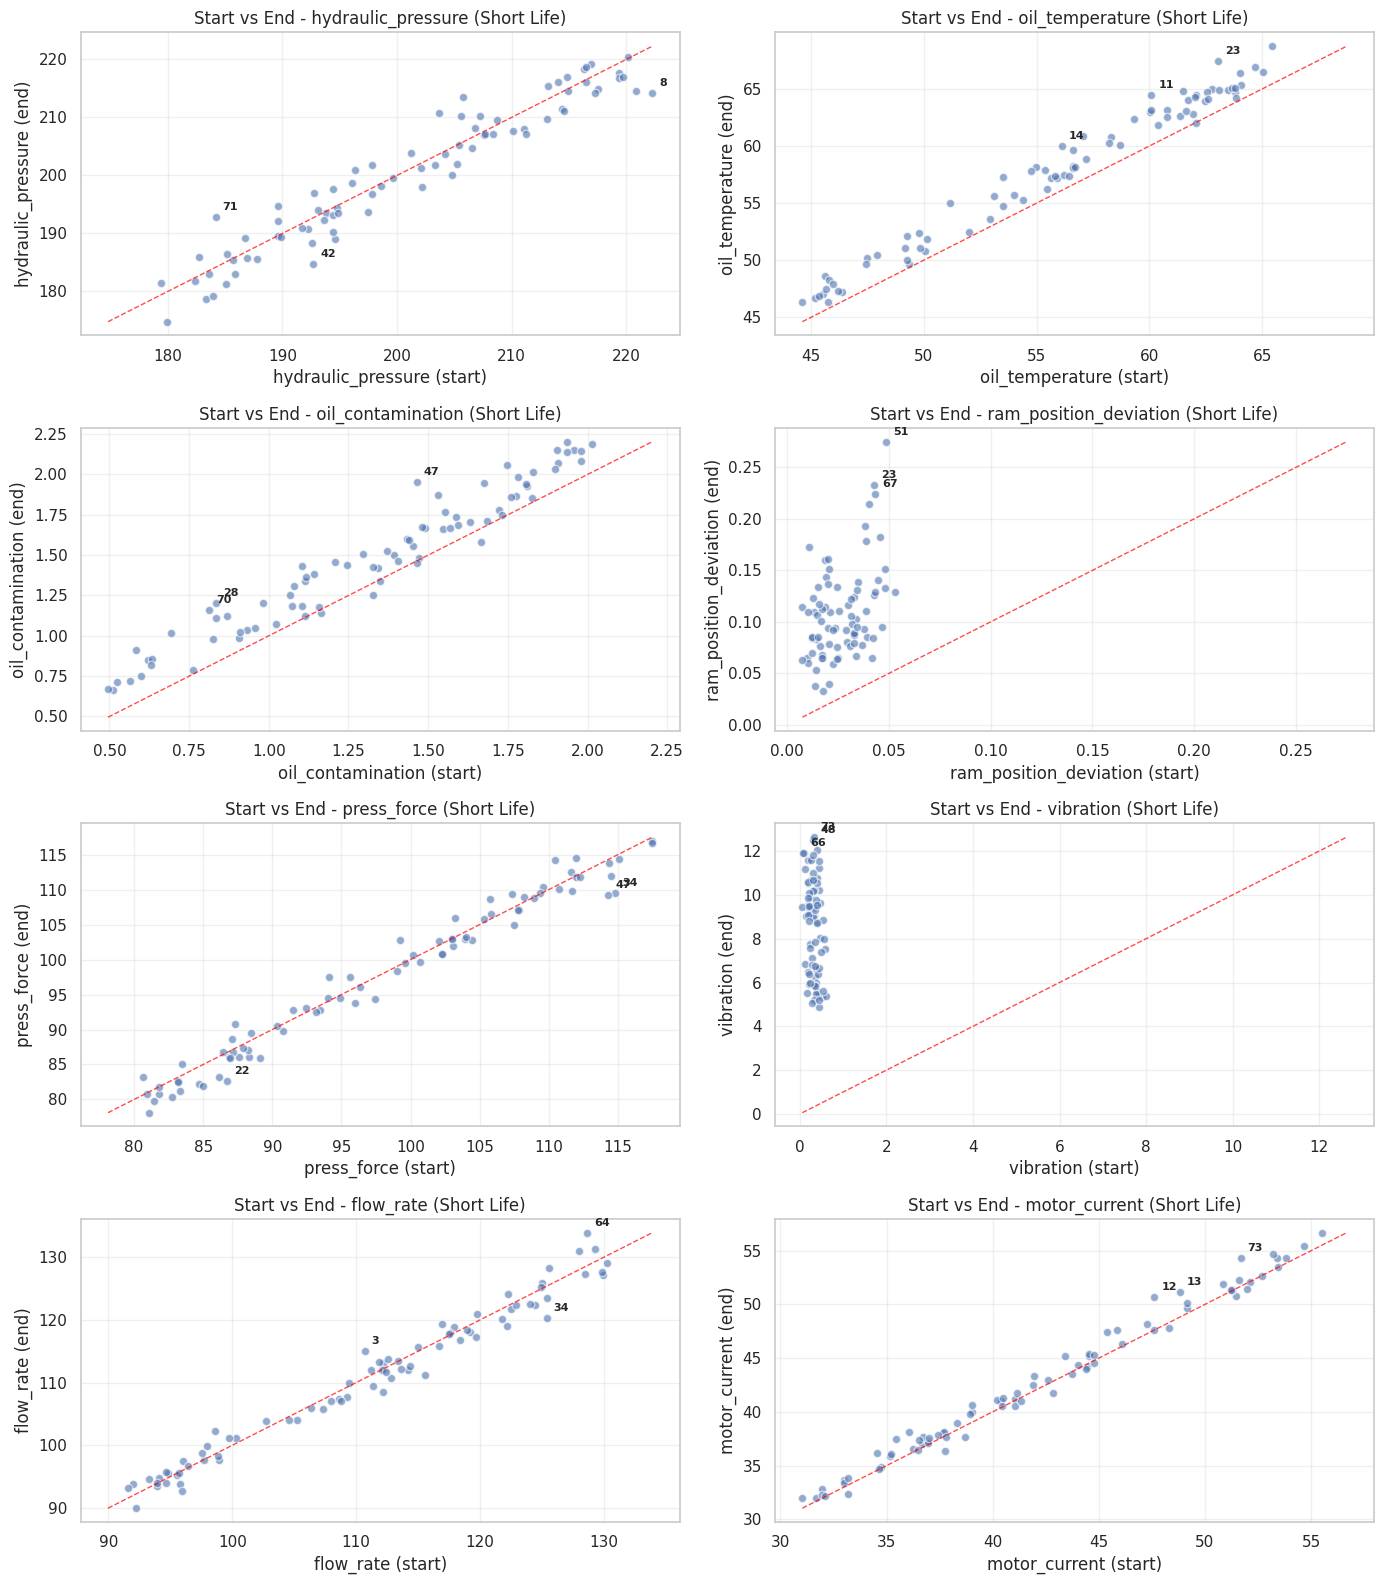


Top Extremes per Sensor ((Short Life))

Largest increase in hydraulic_pressure:
    cycle_id  hydraulic_pressure  hydraulic_pressure_end  hydraulic_pressure_delta
70        71             184.162                 192.753                     8.591
78        79             205.737                 213.517                     7.780
74        75             203.637                 210.774                     7.137
Largest decrease in hydraulic_pressure:
    cycle_id  hydraulic_pressure  hydraulic_pressure_end  hydraulic_pressure_delta
7          8             222.267                 214.192                    -8.075
41        42             192.678                 184.775                    -7.903
51        52             220.811                 214.506                    -6.305

Largest increase in oil_temperature:
    cycle_id  oil_temperature  oil_temperature_end  oil_temperature_delta
10        11           60.088               64.476                  4.388
22        23           63.058

,cycle_id,hydraulic_pressure,oil_temperature,oil_contamination,ram_position_deviation,hydraulic_pressure_end,oil_temperature_end,oil_contamination_end,ram_position_deviation_end
0,1,197.011,47.180,1.713,0.026,154.549,319.695,9.352,13.093
1,2,200.667,46.101,1.275,0.042,129.694,768.049,43.487,9.568
2,3,183.724,58.589,1.063,0.037,117.894,306.339,20.840,33.735
3,4,195.507,61.683,1.792,0.032,168.252,331.846,23.127,12.820
4,5,182.709,45.547,0.662,0.027,112.285,383.540,39.476,15.236
5,6,209.115,63.201,1.165,0.016,135.797,832.692,37.989,34.061
6,7,206.498,55.089,0.774,0.036,173.843,287.108,14.493,5.631
7,8,216.213,46.155,0.853,0.036,169.339,386.714,27.152,8.644



Delta summary (Long Life) (end - start):
                              count     mean      std      min      25%      50%      75%      max
hydraulic_pressure_delta       30.0  -57.942   28.865 -130.467  -70.836  -47.490  -39.410  -12.361
oil_temperature_delta          30.0  392.362  227.651  140.106  235.952  304.446  554.330  915.572
oil_contamination_delta        30.0   30.667   17.279    7.526   16.276   29.247   42.501   81.966
ram_position_deviation_delta   30.0   17.744   10.323    5.595   10.199   13.864   22.677   47.253
press_force_delta              30.0  -39.785   18.185  -83.099  -52.854  -35.212  -29.691  -13.444
vibration_delta                30.0    7.637    2.348    4.181    5.762    7.358    9.910   11.462
flow_rate_delta                30.0  -52.954   31.694 -118.792  -83.943  -43.242  -27.424  -14.547
motor_current_delta            30.0   79.500   52.895   20.520   40.711   58.652   98.072  213.371


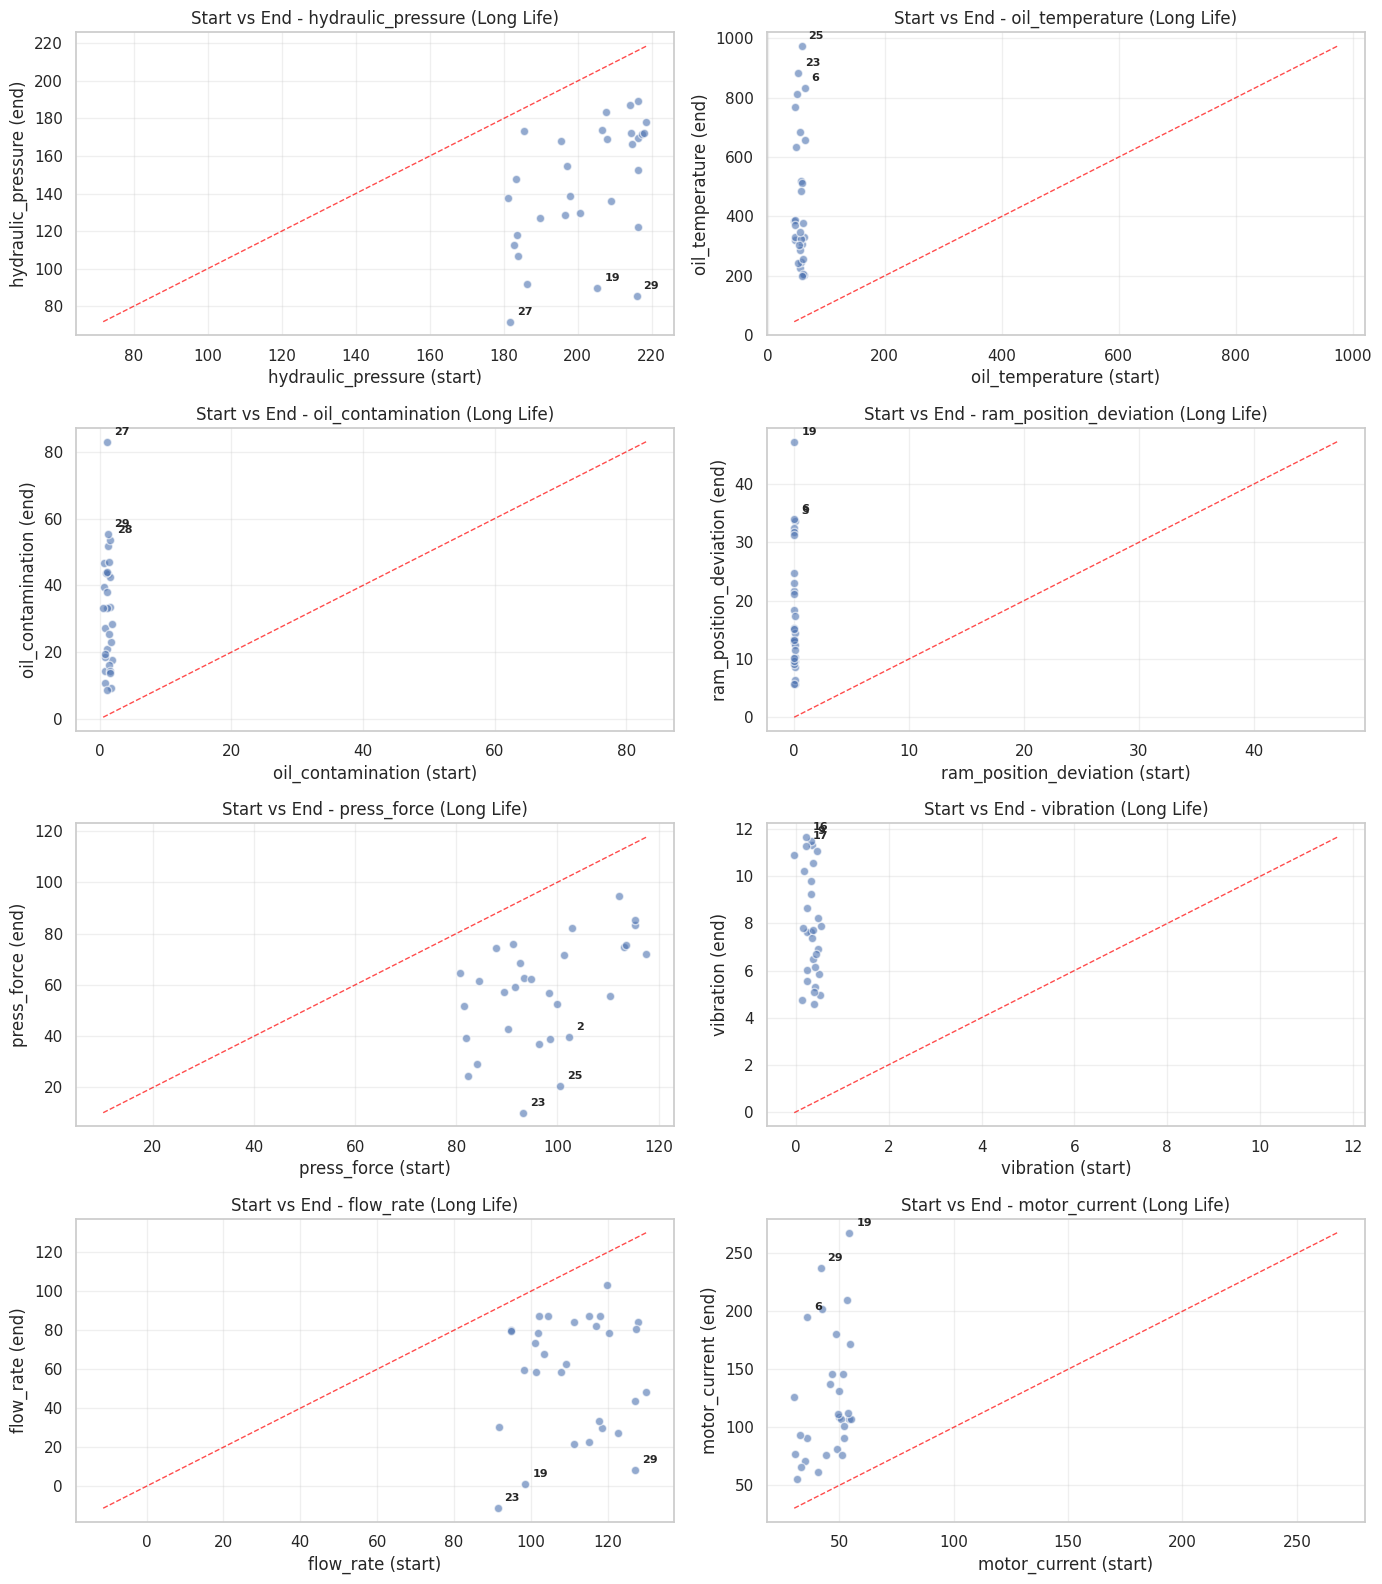


Top Extremes per Sensor ((Long Life))

Largest increase in hydraulic_pressure:
    cycle_id  hydraulic_pressure  hydraulic_pressure_end  hydraulic_pressure_delta
29        30             185.606                 173.245                   -12.361
25        26             207.537                 183.483                   -24.055
13        14             214.148                 187.161                   -26.987
Largest decrease in hydraulic_pressure:
    cycle_id  hydraulic_pressure  hydraulic_pressure_end  hydraulic_pressure_delta
28        29             215.960                  85.493                  -130.467
18        19             205.367                  89.669                  -115.698
26        27             181.749                  71.647                  -110.101

Largest increase in oil_temperature:
    cycle_id  oil_temperature  oil_temperature_end  oil_temperature_delta
24        25           58.136              973.708                915.572
22        23           51.693 

In [9]:
print("2B/ CYCLE COMPARISONS - start vs end summaries and plots")

def cycle_comparison(df_raw, title_suffix=""):
    sensors = [
                "hydraulic_pressure", "oil_temperature", "oil_contamination",
                "ram_position_deviation", "press_force", "vibration",
                "flow_rate", "motor_current"
            ]
    available_sensors = [s for s in sensors if s in df_raw.columns]

    if not available_sensors:
        print(f"No sensors found to compare {title_suffix}")
        return
    else:
        print(f"Comparing sensors {title_suffix}: {available_sensors}")

    df_sorted = df_raw.sort(["cycle_id", "time_min"])

    firsts = df_sorted.group_by("cycle_id").first()
    lasts = df_sorted.group_by("cycle_id").last()

    cols_start = ["cycle_id"] + available_sensors
    cols_end = ["cycle_id"] + available_sensors

    start_end = firsts.select(cols_start).join(
                                                lasts.select(cols_end),
                                                on="cycle_id",
                                                how="inner",
                                                suffix="_end"
                                            )

    for s in available_sensors:
        start_end = start_end.with_columns(
                                                (pl.col(f"{s}_end") - pl.col(s)).alias(f"{s}_delta")
                                            )
        start_end = start_end.with_columns(
                                                (pl.col(f"{s}_delta") / pl.col(s).replace(0, None) * 100).alias(f"{s}_pct_change")
                                            )

    cols_show = ["cycle_id"] + [s for s in available_sensors[:4]] + [f"{s}_end" for s in available_sensors[:4]]
    print(f"\nExample start/end table {title_suffix} (first 8 cycles - sample sensors):")
    display(start_end.select(cols_show).head(8).to_pandas())

    delta_cols = [f"{s}_delta" for s in available_sensors]
    print(f"\nDelta summary {title_suffix} (end - start):")
    print(start_end.select(delta_cols).to_pandas().describe().T)

    start_end_pd = start_end.to_pandas()

    n = len(available_sensors)
    rows, cols = 4, 2
    fig, axes = plt.subplots(rows, cols, figsize=(14, 16))
    axes = axes.flatten()

    for i, s in enumerate(available_sensors):
        ax = axes[i]
        x = start_end_pd[s]
        y = start_end_pd[f"{s}_end"]
        ax.scatter(x, y, alpha=0.6, edgecolors="w")

        lims = [min(x.min(), y.min()), max(x.max(), y.max())]
        ax.plot(lims, lims, "--", color="red", linewidth=1, alpha=0.7)

        ax.set_xlabel(f"{s} (start)")
        ax.set_ylabel(f"{s} (end)")
        ax.set_title(f"Start vs End - {s} {title_suffix}")
        ax.grid(alpha=0.3)

        top3 = start_end_pd.reindex(start_end_pd[f"{s}_delta"].abs().sort_values(ascending=False).index).head(3)
        for _, row in top3.iterrows():
            ax.annotate(
                            int(row["cycle_id"]),
                            (row[s], row[f"{s}_end"]),
                            textcoords="offset points",
                            xytext=(5, 5),
                            fontsize=8,
                            fontweight="bold"
                        )

    for j in range(n, rows * cols):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"\nTop Extremes per Sensor ({title_suffix})")
    for s in available_sensors[:3]:
        print(f"\nLargest increase in {s}:")
        print(start_end_pd[["cycle_id", s, f"{s}_end", f"{s}_delta"]].nlargest(3, f"{s}_delta"))
        print(f"Largest decrease in {s}:")
        print(start_end_pd[["cycle_id", s, f"{s}_end", f"{s}_delta"]].nsmallest(3, f"{s}_delta"))

    print(f"\n{'='*50}\nExplanatory Data Analysis COMPLETED {title_suffix}\n{'='*50}")


cycle_comparison(df_raw_short_life, title_suffix="(Short Life)")
cycle_comparison(df_raw_long_life, title_suffix="(Long Life)")

## 3) Train / Validation / Test split

In [10]:
# 3/ DATASET SPLIT - Cycle-based Train / Val / Test 
print_header("3/ DATASET SPLIT - Cycle-based (Leakage-Free)")

def split_datasets(df_raw, N_TRAIN=0, N_VAL=0, N_TEST=0):
    
    df_use = df_raw.copy()

    assert 'cycle_id' in df_use.columns, "cycle_id column is required"

    # Available cycles
    all_cycles = sorted(df_use['cycle_id'].unique())
    # Deterministic shuffle to avoid cycle-order bias
    rng = np.random.default_rng(seed=42)
    rng.shuffle(all_cycles)
    
    n_cycles = len(all_cycles)
    print(f"Total cycles available: {n_cycles}")

    # fall back if generation is changed with out updating splits
    if n_cycles != (N_TRAIN + N_VAL + N_TEST):
        print("Warning: not enough cycles, using proportional split")
        N_TRAIN = int(0.7 * n_cycles)
        N_VAL = int(0.15 * n_cycles)
        N_TEST = n_cycles - N_TRAIN - N_VAL

    # Deterministic split (cycle-id based, not time-based)
    train_cycles = all_cycles[:N_TRAIN]
    val_cycles = all_cycles[N_TRAIN:N_TRAIN + N_VAL]
    test_cycles = all_cycles[N_TRAIN + N_VAL:N_TRAIN + N_VAL + N_TEST]

    print(f"Train cycles ({len(train_cycles)}): {train_cycles}")
    print(f"Val cycles   ({len(val_cycles)}): {val_cycles}")
    print(f"Test cycles  ({len(test_cycles)}): {test_cycles}")

    # Create RAW splits 
    df_train_raw = df_use[df_use['cycle_id'].isin(train_cycles)].copy()
    df_val_raw = df_use[df_use['cycle_id'].isin(val_cycles)].copy()
    df_test_raw = df_use[df_use['cycle_id'].isin(test_cycles)].copy()

    # Sanity checks
    assert set(train_cycles).isdisjoint(val_cycles)
    assert set(train_cycles).isdisjoint(test_cycles)
    assert set(val_cycles).isdisjoint(test_cycles)

    print("\nRow counts (RAW data):")
    print(f"  Train: {df_train_raw.shape[0]} rows")
    print(f"    Val: {df_val_raw.shape[0]} rows")
    print(f"  Test:  {df_test_raw.shape[0]} rows")

    return df_train_raw, df_val_raw, df_test_raw

# Clear memory for pandas
def safe_free(vars_list):
    for v in vars_list:
        if v in globals():
            try:
                del globals()[v]
            except Exception:
                pass
    gc.collect()

safe_free(['df_raw_long_life', 'df_raw_short_life', 'df_long_life', 'df_short_life'])
print("Attempted to free raw DataFrames and GC run.\n")

df_long_life = pd.read_parquet(long_parquet)
df_short_life = pd.read_parquet(short_parquet)


df_train_raw_short_life, df_val_raw_short_life, df_test_raw_short_life = split_datasets(df_short_life, N_TRAIN=54, N_VAL=13, N_TEST=13)

print("\n" + "="*70 + "\n")

df_train_raw_long_life, df_val_raw_long_life, df_test_raw_long_life = split_datasets(df_long_life, N_TRAIN=20, N_VAL=5, N_TEST=5)

print_footer("DATA SPLIT COMPLETE")


3/ DATASET SPLIT - Cycle-based (Leakage-Free)
Attempted to free raw DataFrames and GC run.

Total cycles available: 80
Train cycles (54): [34, 52, 41, 29, 62, 26, 1, 61, 22, 38, 19, 43, 27, 58, 51, 5, 28, 25, 18, 8, 30, 72, 80, 76, 56, 70, 6, 2, 59, 44, 3, 46, 64, 74, 21, 68, 73, 33, 40, 24, 77, 60, 16, 10, 32, 53, 17, 45, 49, 47, 57, 63, 4, 35]
Val cycles   (13): [31, 11, 69, 75, 55, 50, 7, 39, 71, 12, 79, 42, 23]
Test cycles  (13): [20, 36, 65, 48, 13, 54, 15, 14, 67, 37, 66, 78, 9]

Row counts (RAW data):
  Train: 99808 rows
    Val: 26545 rows
  Test:  24350 rows


Total cycles available: 30
Train cycles (20): [30, 17, 8, 26, 25, 23, 6, 22, 27, 11, 20, 21, 10, 7, 19, 4, 1, 16, 18, 24]
Val cycles   (5): [13, 12, 15, 29, 3]
Test cycles  (5): [5, 28, 2, 14, 9]

Row counts (RAW data):
  Train: 6998608 rows
    Val: 2195924 rows
  Test:  2230941 rows

----------------------------------------------------------------------
DATA SPLIT COMPLETE
---------------------------------------------


3A/ SPLIT VISUALIZATION - cycles, RUL & sensor distributions
Dataset         : (Short Life)
Selected sensor : vibration
Train cycles    : 54
Val cycles      : 13
Test cycles     : 13


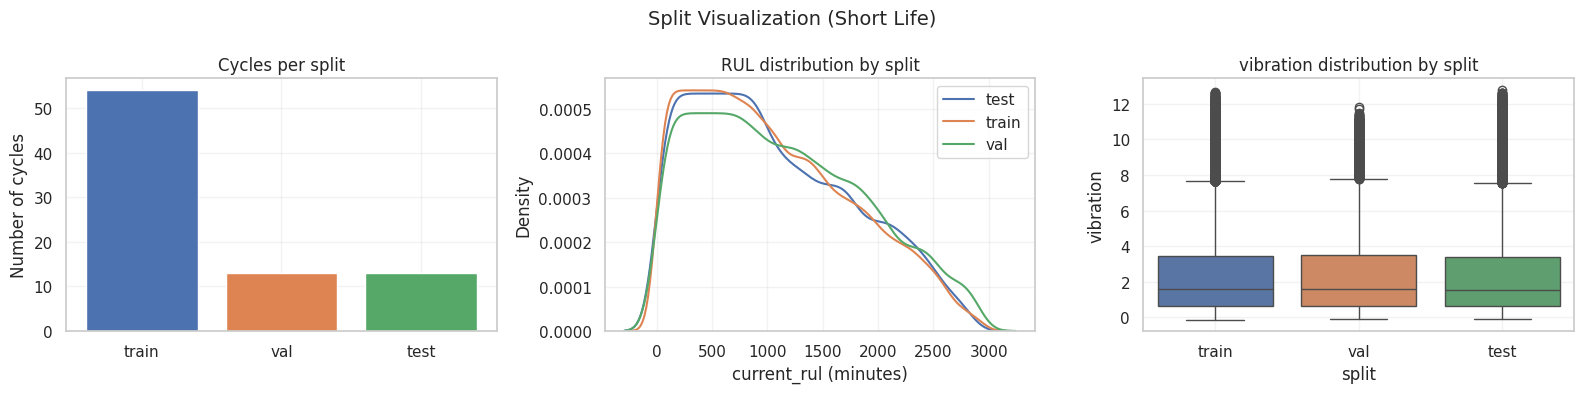


----------------------------------------------------------------------
SPLIT VISUALIZATION COMPLETE (Short Life)
----------------------------------------------------------------------
Dataset         : (Long Life)
Selected sensor : vibration
Train cycles    : 20
Val cycles      : 5
Test cycles     : 5


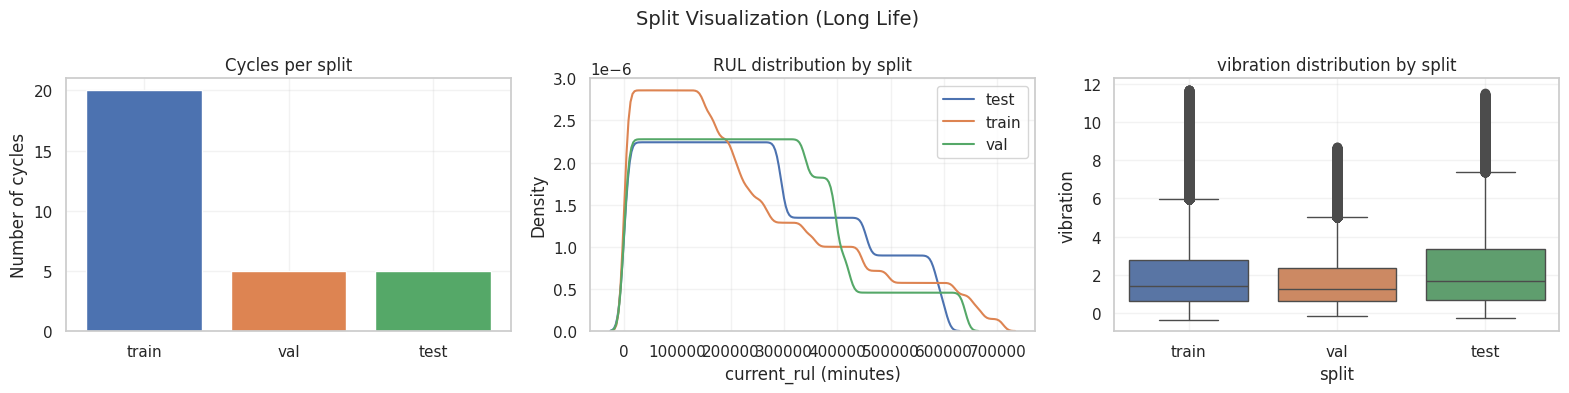


----------------------------------------------------------------------
SPLIT VISUALIZATION COMPLETE (Long Life)
----------------------------------------------------------------------


In [11]:
# 3A/ Split Visualization - cycles, RUL & sensor distributions
print_header("3A/ SPLIT VISUALIZATION - cycles, RUL & sensor distributions")

def visualize_splits(df_train, df_val, df_test, title_suffix=""):
    # Ensure RUL is present
    assert 'current_rul' in df_train.columns, "current_rul missing in selected split dataframe"

    # Choose a sensor to visualize (prefer 'vibration' or fallback)
    preferred = 'vibration'
    if preferred in df_train.columns:
        sensor_col = preferred
    else:
        exclude = {'cycle_id', 'time_min', 'timestamp', 'total_rul', 'current_rul'}
        numeric = get_numeric_sensor_cols(df_train, exclude)
        sensor_col = numeric[0] if len(numeric) > 0 else None

    assert sensor_col is not None, "No suitable sensor or feature column found for visualization"

    # Prepare combined dataframe for easy plotting
    def tag_split(df, name):
        d = df[[sensor_col, 'current_rul', 'cycle_id']].copy()
        d['split'] = name
        return d

    plot_df = pd.concat([
                            tag_split(df_train, 'train'),
                            tag_split(df_val, 'val'),
                            tag_split(df_test, 'test')
                        ], ignore_index=True)

    print_kv([
                ('Dataset', title_suffix),
                ('Selected sensor', sensor_col),
                ('Train cycles', df_train['cycle_id'].nunique()),
                ('Val cycles', df_val['cycle_id'].nunique()),
                ('Test cycles', df_test['cycle_id'].nunique())
            ])

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Cycles per split
    counts = [df_train['cycle_id'].nunique(),
              df_val['cycle_id'].nunique(),
              df_test['cycle_id'].nunique()]
    axes[0].bar(['train', 'val', 'test'], counts,
                color=['#4c72b0', '#dd8452', '#55a868'])
    axes[0].set_title('Cycles per split')
    axes[0].set_ylabel('Number of cycles')
    axes[0].grid(alpha=0.25)

    # RUL distribution (overlayed KDEs)
    for name, grp in plot_df.groupby('split'):
        sns.kdeplot(grp['current_rul'], ax=axes[1], label=name, fill=False)
    axes[1].set_title('RUL distribution by split')
    axes[1].set_xlabel('current_rul (minutes)')
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    # Sensor distribution (boxplot)
    sns.boxplot(x='split', y=sensor_col, data=plot_df,
                ax=axes[2], palette=['#4c72b0', '#dd8452', '#55a868'])
    axes[2].set_title(f'{sensor_col} distribution by split')
    axes[2].grid(alpha=0.25)

    plt.suptitle(f"Split Visualization {title_suffix}", fontsize=14)
    plt.tight_layout()
    plt.show()

    print_footer(f"SPLIT VISUALIZATION COMPLETE {title_suffix}")


# Run for both datasets
visualize_splits(df_train_raw_short_life, df_val_raw_short_life, df_test_raw_short_life, title_suffix="(Short Life)")
visualize_splits(df_train_raw_long_life, df_val_raw_long_life, df_test_raw_long_life, title_suffix="(Long Life)")

## 4) Feature Engineering

In [12]:
# 4/ FEATURE ENGINEERING - Critical-Aware (Dual Pipeline)
print_header("4/ FEATURE ENGINEERING - Causal & Critical-Aware")

# Ensure datasets are loaded
assert 'df_train_raw_long_life' in globals()
assert 'df_train_raw_short_life' in globals()

SENSORS = [
            'hydraulic_pressure',
            'oil_temperature',
            'oil_contamination',
            'ram_position_deviation',
            'press_force',
            'vibration',
            'flow_rate',
            'motor_current'
        ]

WINDOW_SHORT = 5
WINDOW_LONG = 20

def engineer_features_streaming(df: pd.DataFrame, sensors=None, window_short=5, window_long=20):
    if sensors is None:
        sensors = SENSORS 
    out_chunks = []
    # groupby iterator, work on each group and then let go of memory
    for cycle_id, grp in df.groupby('cycle_id', sort=True):
        g = grp.sort_values('time_min').copy()
        # rolling temel feature'lar
        for s in sensors:
            g[f"{s}_roll_mean_{window_short}"] = g[s].rolling(window_short, min_periods=1).mean()
            g[f"{s}_roll_mean_{window_long}"] = g[s].rolling(window_long, min_periods=1).mean()
            g[f"{s}_roll_std_{window_long}"] = g[s].rolling(window_long, min_periods=2).std().fillna(0)
            g[f"{s}_dev_long"] = g[s] - g[f"{s}_roll_mean_{window_long}"]
            g[f"{s}_slope_{window_long}"] = g[f"{s}_roll_mean_{window_long}"].diff().fillna(0)

        # interaction
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = (g['press_force'] / g['hydraulic_pressure']).replace([np.inf, -np.inf], np.nan)
        g['force_pressure_coupling'] = ratio.fillna(1.0).clip(0, 10)

        # energy & stability
        g['vibration_energy'] = g['vibration'].rolling(window_short, min_periods=1).mean() ** 2
        pressure_std = g['hydraulic_pressure_roll_std_20'].clip(lower=1e-4)
        g['pressure_stability'] = np.log1p(1.0 / pressure_std)

        # critical aware
        for s in ['vibration', 'oil_temperature', 'motor_current']:
            g[f"{s}_acceleration"] = g[f"{s}_slope_{window_long}"].diff(5).fillna(0)

        for s in sensors:
            roll_std_short = g[s].rolling(5, min_periods=2).std()
            g[f"{s}_volatility_surge"] = (roll_std_short - g[f"{s}_roll_std_{window_long}"]).clip(lower=0)

        # degradation index (per-cycle normalize)
        def safe_norm(x):
            mn = x.min()
            mx = x.max()
            denom = (mx - mn) if (mx - mn) > 0 else 1.0
            return (x - mn) / denom

        g_vib = safe_norm(g['vibration'])
        g_oil_t = safe_norm(g['oil_temperature'])
        g_pressure_inv = 1 - safe_norm(g['hydraulic_pressure'])
        g_cont = safe_norm(g['oil_contamination'])

        g['degradation_index'] = (g_vib + g_oil_t + g_pressure_inv + g_cont) / 4.0

        # recent max
        for s in ['vibration', 'motor_current']:
            g[f"{s}_max_10"] = g[s].rolling(window=10, min_periods=1).max()

        # ffill small missing values that may appear
        g.fillna(0, inplace=True)

        out_chunks.append(g)

        # relax the memory 
        if len(out_chunks) >= 50:
            # limit memory usage before returning by temporarily concatenating.
            out_df = pd.concat(out_chunks, axis=0)
            yield out_df
            out_chunks = []

    if out_chunks:
        yield pd.concat(out_chunks, axis=0)

def engineer_features(df):
    parts = []
    for chunk in engineer_features_streaming(df):
        parts.append(chunk)
    return pd.concat(parts, axis=0).reset_index(drop=True)

# PIPELINE 1 - SHORT LIFE
print("\nProcessing SHORT LIFE Dataset (For Stage 1 & 2 Models)")
df_train_short = engineer_features(df_train_raw_short_life)
df_val_short   = engineer_features(df_val_raw_short_life)
df_test_short  = engineer_features(df_test_raw_short_life)

assert df_train_short.shape[0] == df_train_raw_short_life.shape[0]
assert df_val_short.shape[0] == df_val_raw_short_life.shape[0]
assert df_test_short.shape[0] == df_test_raw_short_life.shape[0]

# PIPELINE 2 - LONG LIFE
print("\nProcessing LONG LIFE Dataset (For Base Model)")
df_train_long = engineer_features(df_train_raw_long_life)
df_val_long   = engineer_features(df_val_raw_long_life)
df_test_long  = engineer_features(df_test_raw_long_life)

assert df_train_long.shape[0] == df_train_raw_long_life.shape[0]
assert df_val_long.shape[0] == df_val_raw_long_life.shape[0]
assert df_test_long.shape[0] == df_test_raw_long_life.shape[0]

# SUMMARY
new_features = sorted(
                        set(df_train_short.columns) - set(df_train_raw_short_life.columns)
                    )

print("\nFeature engineering summary:")
print(f"  New features created: {len(new_features)}")
print(f"  Short Life Train: {df_train_short.shape} | Long Life Train: {df_train_long.shape}")
print(f"  Sample features: {new_features[:5]}")

print_footer("FEATURE ENGINEERING COMPLETE")



4/ FEATURE ENGINEERING - Causal & Critical-Aware

Processing SHORT LIFE Dataset (For Stage 1 & 2 Models)

Processing LONG LIFE Dataset (For Base Model)

Feature engineering summary:
  New features created: 57
  Short Life Train: (99808, 69) | Long Life Train: (6998608, 69)
  Sample features: ['degradation_index', 'flow_rate_dev_long', 'flow_rate_roll_mean_20', 'flow_rate_roll_mean_5', 'flow_rate_roll_std_20']

----------------------------------------------------------------------
FEATURE ENGINEERING COMPLETE
----------------------------------------------------------------------


## 5) Feature Selection

In [ ]:
# 5/ FEATURE SELECTION
print_header("5/ FEATURE SELECTION")

# Preconditions
assert 'df_train_short' in globals()
assert 'df_train_long' in globals()

TARGET_COL = 'current_rul'
EXCLUDE_COLS = {'cycle_id', 'time_min', 'timestamp', 'total_rul', TARGET_COL}

# Feature Candidate Discovery
feature_cols = [
                    c for c in df_train_short.columns
                    if c not in EXCLUDE_COLS and pd.api.types.is_numeric_dtype(df_train_short[c])
                ]

print(f"Initial feature count: {len(feature_cols)}")

# Correlation Filtering (Short-Life ONLY)
print("\nCorrelation filtering (Short-Life only, downsampled)")

# aggressive but safe sampling
corr_sample = df_train_short.sample(
                                        n=min(100_000, len(df_train_short)),
                                        random_state=42
                                    )

X_corr = corr_sample[feature_cols].fillna(0)

corr_matrix = X_corr.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

corr_threshold = 0.95
to_drop = [c for c in upper.columns if any(upper[c] > corr_threshold)]

features_after_corr = [f for f in feature_cols if f not in to_drop]

print(f"  Dropped due to correlation: {len(to_drop)}")
print(f"  Remaining features: {len(features_after_corr)}")

del corr_matrix, upper, X_corr, corr_sample

# Importance via XGBoost (Short-Life ONLY)
print("\nXGBoost importance (Short-Life only, stratified sample)")

# Stratified sampling by RUL regime
critical = df_train_short[df_train_short[TARGET_COL] <= 20]
mid = df_train_short[
                        (df_train_short[TARGET_COL] > 20) &
                        (df_train_short[TARGET_COL] <= 500)
                    ]
healthy = df_train_short[df_train_short[TARGET_COL] > 500]

imp_df = pd.concat([
                        critical,
                        mid.sample(n=min(len(mid), 40_000), random_state=42),
                        healthy.sample(n=min(len(healthy), 40_000), random_state=42)
                    ])

X_imp = imp_df[features_after_corr].fillna(0)
y_imp = imp_df[TARGET_COL]
y_imp_norm = y_imp / y_imp.max()

importances_accum = pd.Series(0.0, index=features_after_corr)

for seed in [41, 42, 43]:
    model = XGBRegressor(
                            n_estimators=150,
                            max_depth=5,
                            learning_rate=0.1,
                            subsample=0.8,
                            colsample_bytree=0.8,
                            random_state=seed,
                            n_jobs=4,          # WSL friendly
                            verbosity=0
                        )
    model.fit(X_imp, y_imp_norm)
    importances_accum += model.feature_importances_

importances = (importances_accum / 3).sort_values(ascending=False)

print("\nTop 15 important features:")
for i, (f, v) in enumerate(importances.head(15).items(), 1):
    print(f"  {i:2d}. {f:35s} {v:.4f}")


# Final Feature Selection Logic
top_n = 20
cumulative = importances.cumsum()
selected_features = cumulative[cumulative <= 0.95].index.tolist()
selected_features = selected_features[:top_n]

print(f"\nSelected feature count: {len(selected_features)}")


# Persist Feature List
cache_file = os.path.join(save_path, "selected_process_pump_features.json")
with open(cache_file, "w") as f:
    json.dump(selected_features, f, indent=4)

print(f"Saved feature list to: {cache_file}")


# Apply to Both Pipelines
print("\nApplying feature selection to datasets...")

# Short-Life
X_train_short = df_train_short[selected_features]
y_train_short = df_train_short[TARGET_COL]
X_val_short   = df_val_short[selected_features]
y_val_short   = df_val_short[TARGET_COL]
X_test_short  = df_test_short[selected_features]
y_test_short  = df_test_short[TARGET_COL]

# Long-Life
X_train_long = df_train_long[selected_features]
y_train_long = df_train_long[TARGET_COL]
X_val_long   = df_val_long[selected_features]
y_val_long   = df_val_long[TARGET_COL]
X_test_long  = df_test_long[selected_features]
y_test_long  = df_test_long[TARGET_COL]

# Sanity checks
assert len(selected_features) > 0
assert X_train_short.shape[1] == X_train_long.shape[1]

print("\nFinal Shapes:")
print(f"  Short-Life Train: {X_train_short.shape}")
print(f"  Long-Life Train : {X_train_long.shape}")

print_footer("FEATURE SELECTION v2 COMPLETE")



5/ FEATURE SELECTION - Memory Safe Dual Pipeline v2
Initial feature count: 65

[Step 1] Correlation filtering (Short-Life only, downsampled)
  Dropped due to correlation: 18
  Remaining features: 47

[Step 2] XGBoost importance (Short-Life only, stratified sample)

Top 15 important features:
   1. vibration_energy                    0.3341
   2. vibration                           0.2492
   3. degradation_index                   0.1188
   4. flow_rate_roll_std_20               0.0293
   5. press_force                         0.0283
   6. oil_contamination                   0.0277
   7. oil_temperature                     0.0243
   8. press_force_roll_std_20             0.0201
   9. vibration_roll_std_20               0.0200
  10. flow_rate                           0.0189
  11. force_pressure_coupling             0.0184
  12. hydraulic_pressure                  0.0177
  13. motor_current                       0.0141
  14. ram_position_deviation_roll_std_20  0.0108
  15. oil_temperatur

In [ ]:
# 5A/ Feature stats saving - Min / Max per selected feature
print_header("5A/ FEATURE STATS SAVING - Min / Max per selected feature")

# Load selected features from saved cache or from runtime variable
cache_file = os.path.join(save_path, "selected_process_pump_features.json")
if os.path.exists(cache_file):
    with open(cache_file, "r", encoding="utf-8") as f:
        selected_feature_list = json.load(f)
elif "selected_features" in globals():
    selected_feature_list = selected_features
else:
    raise RuntimeError("Selected feature list not found in cache or globals")

if not isinstance(selected_feature_list, (list, tuple)) or len(selected_feature_list) == 0:
    raise RuntimeError("Selected feature list is empty or invalid")

required_cols = list(selected_feature_list)

# initialize min and max containers
mins = {c: float("inf") for c in required_cols}
maxs = {c: float("-inf") for c in required_cols}

# gather available dataframes to compute statistics
dataframe_names = [
                    "X_train_short",
                    "X_val_short",
                    "X_test_short",
                    "X_train_long",
                    "X_val_long",
                    "X_test_long",
                ]

dataframes_to_scan = []
for name in dataframe_names:
    if name in globals():
        df_candidate = globals()[name]
        # ensure pandas DataFrame
        if hasattr(df_candidate, "shape") and isinstance(df_candidate, (pd.DataFrame,)):
            dataframes_to_scan.append(df_candidate)
        else:
            try:
                df_converted = pd.DataFrame(df_candidate)
                dataframes_to_scan.append(df_converted)
            except Exception:
                pass

if len(dataframes_to_scan) == 0:
    raise RuntimeError("No suitable split dataframes found to compute feature stats")

# compute mins and maxs across available dataframes
for df in dataframes_to_scan:
    for c in required_cols:
        if c not in df.columns:
            print(f"Warning feature missing in dataframe {c}")
            continue
        col_series = df[c].dropna()
        if col_series.shape[0] == 0:
            continue
        try:
            col_min = float(col_series.min())
            col_max = float(col_series.max())
        except Exception:
            # fallback using numpy
            arr = np.asarray(col_series)
            if arr.size == 0:
                continue
            col_min = float(np.nanmin(arr))
            col_max = float(np.nanmax(arr))
        mins[c] = min(mins[c], col_min)
        maxs[c] = max(maxs[c], col_max)

# verify results and replace infinities if any
for c in required_cols:
    if mins[c] == float("inf"):
        mins[c] = None
    if maxs[c] == float("-inf"):
        maxs[c] = None

feature_stats = {c: {"min": mins[c], "max": maxs[c]} for c in required_cols}

out_path = Path(save_path) / "process_pump_feature_stats.json"
out_path.parent.mkdir(parents=True, exist_ok=True)

with open(out_path, "w", encoding="utf-8") as f:
    json.dump(feature_stats, f, indent=2)

print("Saved:", out_path.as_posix())
print(json.dumps(feature_stats, indent=2))

print_footer("FEATURE STATS SAVING COMPLETE")


5A/ FEATURE STATS SAVING - Min / Max per selected feature
Saved: models_and_features/hydraulic_press/process_pump_feature_stats.json
{
  "vibration_energy": {
    "min": 8.954561494957353e-10,
    "max": 159.40529699185214
  },
  "vibration": {
    "min": -0.34894048989274523,
    "max": 12.78991594128226
  },
  "degradation_index": {
    "min": 0.005049795134211745,
    "max": 0.9995179561431395
  },
  "flow_rate_roll_std_20": {
    "min": 0.0,
    "max": 3.7349560221353824
  },
  "press_force": {
    "min": 7.382177183695134,
    "max": 124.24860579486712
  },
  "oil_contamination": {
    "min": 0.3896827473292328,
    "max": 83.060607086511
  },
  "oil_temperature": {
    "min": 43.814196481563556,
    "max": 973.707602383521
  },
  "press_force_roll_std_20": {
    "min": 0.0,
    "max": 3.4589924778395047
  },
  "vibration_roll_std_20": {
    "min": 0.0,
    "max": 0.33968955620821645
  },
  "flow_rate": {
    "min": -11.716012397141466,
    "max": 135.86230814379022
  },
  "force

## 6) Model Training (XGBoost)

In [15]:
# 6/ MODEL TRAINING - Optimized XGBoost for RUL Prediction
print_header("6/ MODEL TRAINING - Optimized XGBoost for RUL Prediction")

# Validate preconditions
assert 'selected_features' in globals(), "Feature selection not found. Run step 5 first."
assert 'X_train_long' in globals() and 'y_train_long' in globals(), "Training data missing. Run step 5 first."
assert 'X_val_long' in globals() and 'y_val_long' in globals(), "Validation data missing. Run step 5 first."
assert 'X_test_long' in globals() and 'y_test_long' in globals(), "Test data missing. Run step 5 first."

print(f"     Train set: {X_train_long.shape}")
print(f"Validation set: {X_val_long.shape}")
print(f"      Test set: {X_test_long.shape}")

# Initialize model with enhanced parameters
base_model = XGBRegressor(
                            n_estimators=800,
                            max_depth=4,
                            learning_rate=0.02,
                            min_child_weight=5,
                            subsample=0.7,
                            colsample_bytree=0.7,
                            gamma=0.2,
                            reg_alpha=0.2,
                            reg_lambda=1.5,
                            objective="reg:absoluteerror",
                            random_state=42,
                            n_jobs=-1,
                            tree_method="hist"
                        )

# Define adaptive sample weights with progressive scaling
print("\nTraining model with adaptive weighting...")

sample_weights = np.ones_like(y_train_long, dtype=float)

sample_weights += np.clip((500 - y_train_long) / 500, 0, 1) * 1.0
sample_weights += np.clip((100 - y_train_long) / 100, 0, 1) * 1.5

# Train with validation monitoring
base_model.fit(
                X_train_long,
                y_train_long,
                sample_weight=sample_weights,
                eval_set=[(X_val_long, y_val_long)],
                eval_metric="mae",
                early_stopping_rounds=50,
                verbose=50
            )

print(f"\nTraining complete. Best iteration: {base_model.best_iteration}")

# Generate predictions
y_val_pred = base_model.predict(X_val_long)
y_test_pred = base_model.predict(X_test_long)

# Ensure predictions are within valid range
MAX_RUL = int(y_train_long.max())

# Light smoothing to reduce single step noise
y_test_pred = pd.Series(y_test_pred).rolling(window=3, min_periods=1).mean().values

y_val_pred = np.clip(y_val_pred, 0, MAX_RUL)
y_test_pred = np.clip(y_test_pred, 0, MAX_RUL)

# Calculate evaluation metrics
val_mae = MAE(y_val_long, y_val_pred)
val_rmse = R_MSE(y_val_long, y_val_pred)
val_r2 = r2_score(y_val_long, y_val_pred)

test_mae = MAE(y_test_long, y_test_pred)
test_rmse = R_MSE(y_test_long, y_test_pred)
test_r2 = r2_score(y_test_long, y_test_pred)

print("\nMODEL PERFORMANCE:")
print(f"Validation MAE: {val_mae:.2f}, RMSE: {val_rmse:.2f}, R2: {val_r2:.4f}")
print(f"Test       MAE: {test_mae:.2f}, RMSE: {test_rmse:.2f}, R2: {test_r2:.4f}")

# Critical region analysis
print("\nCRITICAL REGION ANALYSIS (RUL <= 20):")

for set_name, y_true, y_pred in [
                                    ("Validation", y_val_long, y_val_pred),
                                    ("Test", y_test_long, y_test_pred)
                                ]:
    critical_mask = y_true <= 20
    critical_sample_count = critical_mask.sum()

    if critical_sample_count == 0:
        print(f"{set_name}: No critical samples found")
        continue

    critical_mae = MAE(y_true[critical_mask], y_pred[critical_mask])
    accuracy_10min = (np.abs(y_true[critical_mask] - y_pred[critical_mask]) <= 10).mean() * 100

    print(f"\n{set_name}:")
    print(f"Samples: {critical_sample_count}")
    print(f"MAE: {critical_mae:.2f}")
    print(f"Accuracy plus minus 10 minutes: {accuracy_10min:.1f}%")

# Save model
base_model.save_model(f"{save_path}hydraulic_press_base_model.json")
print(f"Model saved: {save_path}hydraulic_press_base_model.json")

print_footer("MODEL TRAINING COMPLETED")



6/ MODEL TRAINING - Optimized XGBoost for RUL Prediction
     Train set: (6998608, 16)
Validation set: (2195924, 16)
      Test set: (2230941, 16)

Training model with adaptive weighting...
[0]	validation_0-mae:124113.55484
[50]	validation_0-mae:74866.93453
[100]	validation_0-mae:57969.78996
[150]	validation_0-mae:49948.70275
[200]	validation_0-mae:48742.96564
[250]	validation_0-mae:48440.54185
[300]	validation_0-mae:48968.07686
[316]	validation_0-mae:49402.73897

Training complete. Best iteration: 266

MODEL PERFORMANCE:
Validation MAE: 48219.94, RMSE: 78253.93, R2: 0.7265
Test       MAE: 67821.32, RMSE: 101737.55, R2: 0.5877

CRITICAL REGION ANALYSIS (RUL <= 20):

Validation:
Samples: 105
MAE: 13235.65
Accuracy plus minus 10 minutes: 0.0%

Test:
Samples: 105
MAE: 10983.36
Accuracy plus minus 10 minutes: 0.0%
Model saved: models_and_features/hydraulic_press/hydraulic_press_base_model.json

----------------------------------------------------------------------
MODEL TRAINING COMPLETED

## 7) Model Evaluation

In [16]:
# 7/ MODEL EVALUATION - BASE MODEL PERFORMANCE (LONG-LIFE FOCUS)
print_header("MODEL EVALUATION - Base Model Long-Life Analysis - HYDRAULIC PRESS")

# Preconditions check
assert 'y_test_long' in globals() and 'y_test_pred' in globals()
assert 'y_val_long' in globals() and 'y_val_pred' in globals()

# OVERALL PERFORMANCE
print("\n=== OVERALL PERFORMANCE (0 - 500,000 min) ===")

val_mae  = MAE(y_val_long, y_val_pred)
val_rmse = R_MSE(y_val_long, y_val_pred)
val_r2   = r2_score(y_val_long, y_val_pred)

test_mae  = MAE(y_test_long, y_test_pred)
test_rmse = R_MSE(y_test_long, y_test_pred)
test_r2   = r2_score(y_test_long, y_test_pred)

print("\nVALIDATION (Long Life):")
print(f"   MAE: {val_mae:.2f} min")
print(f"  RMSE: {val_rmse:.2f}")
print(f"   R^2: {val_r2:.4f}")

print("\nTEST (Long Life):")
print(f"   MAE: {test_mae:.2f} min")
print(f"  RMSE: {test_rmse:.2f}")
print(f"   R^2: {test_r2:.4f}")

# RUL STRATIFIED ANALYSIS
print("\n=== RUL STRATIFIED ANALYSIS (TEST SET) ===")

bins = [
    (0, 100),
    (100, 1000),
    (1000, 10000),
    (10000, 100000),
    (100000, 500000)
]

labels = [
    "Near Critical",
    "Short Term",
    "Mid Term",
    "Long Term",
    "Initial Healthy"
]

print(f"{'Range':<18s} {'N':>8s} {'MAE':>12s} {'Error %':>10s}")
print("-" * 55)

for (low, high), label in zip(bins, labels):
    mask = (y_test_long >= low) & (y_test_long < high)
    if mask.sum() == 0:
        continue

    mae = MAE(y_test_long[mask], y_test_pred[mask])
    avg_true_rul = y_test_long[mask].mean()
    relative_error_percent = (mae / avg_true_rul) * 100 if avg_true_rul > 0 else 0.0

    print(f"{label:<18s} {mask.sum():8d} {mae:12.2f} {relative_error_percent:9.1f}%")

# CRITICAL REGION DIAGNOSTIC
print("\n=== CRITICAL REGION DIAGNOSTIC (RUL <= 100) ===")

critical_mask = y_test_long <= 100
critical_samples = critical_mask.sum()

if critical_samples > 0:
    critical_mae = MAE(y_test_long[critical_mask], y_test_pred[critical_mask])
    print(f"  Samples found: {critical_samples}")
    print(f"  Base Model MAE in Critical Zone: {critical_mae:.2f} min")
    print("  Interpretation: High error expected. Critical accuracy is handled by Stage 1 and Stage 2 models.")
else:
    print("  No critical samples found in test set.")

# BASE MODEL QUALITY CHECK
print("\n=== BASE MODEL QUALITY CHECK ===")

r2_requirement_passed = test_r2 >= 0.80

mid_long_life_mask = y_test_long > 1000
mid_long_life_mae = MAE(y_test_long[mid_long_life_mask], y_test_pred[mid_long_life_mask])
mid_long_life_avg = y_test_long[mid_long_life_mask].mean()
relative_error_mid_long = (mid_long_life_mae / mid_long_life_avg) * 100

relative_error_requirement_passed = relative_error_mid_long <= 20.0

print(f"  Overall R^2 >= 80%       : {'PASS' if r2_requirement_passed else 'FAIL'} ({test_r2 * 100:.1f}%)")
print(f"  Mid Long Term Err < 20%  : {'PASS' if relative_error_requirement_passed else 'FAIL'} ({relative_error_mid_long:.1f}%)")

print("\nFinal Decision: Base Model suitability is evaluated only for long term planning.")

print_footer("BASE MODEL EVALUATION COMPLETE")



MODEL EVALUATION - Base Model Long-Life Analysis - HYDRAULIC PRESS

=== OVERALL PERFORMANCE (0 - 500,000 min) ===

VALIDATION (Long Life):
   MAE: 48219.94 min
  RMSE: 78253.93
   R^2: 0.7265

TEST (Long Life):
   MAE: 67821.32 min
  RMSE: 101737.55
   R^2: 0.5877

=== RUL STRATIFIED ANALYSIS (TEST SET) ===
Range                     N          MAE    Error %
-------------------------------------------------------
Near Critical           500     11326.02   22880.8%
Short Term             4500     10439.70    1899.9%
Mid Term              45000      7967.64     144.9%
Long Term            450000     14883.45      27.1%
Initial Healthy     1543224     66119.71      24.6%

=== CRITICAL REGION DIAGNOSTIC (RUL <= 100) ===
  Samples found: 505
  Base Model MAE in Critical Zone: 11325.30 min
  Interpretation: High error expected. Critical accuracy is handled by Stage 1 and Stage 2 models.

=== BASE MODEL QUALITY CHECK ===
  Overall R^2 >= 80%       : FAIL (58.8%)
  Mid Long Term Err < 20%  : 


7A/ VISUALIZATION - Predictions vs True RUL


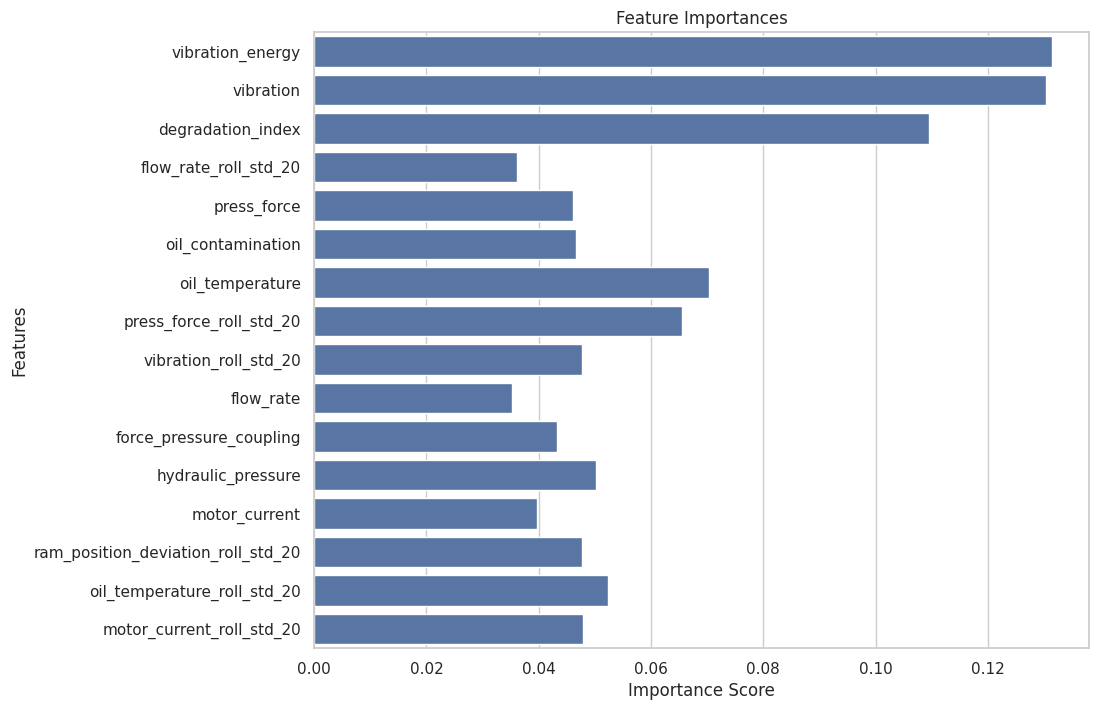

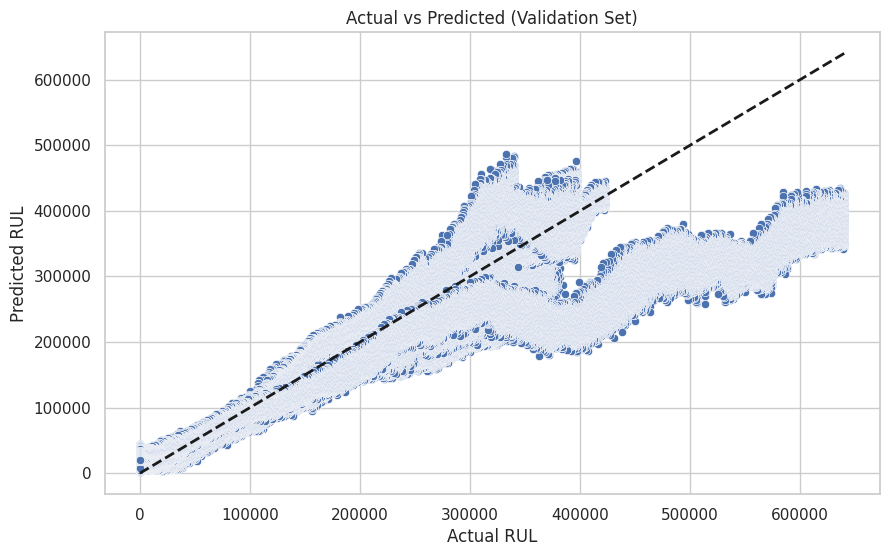

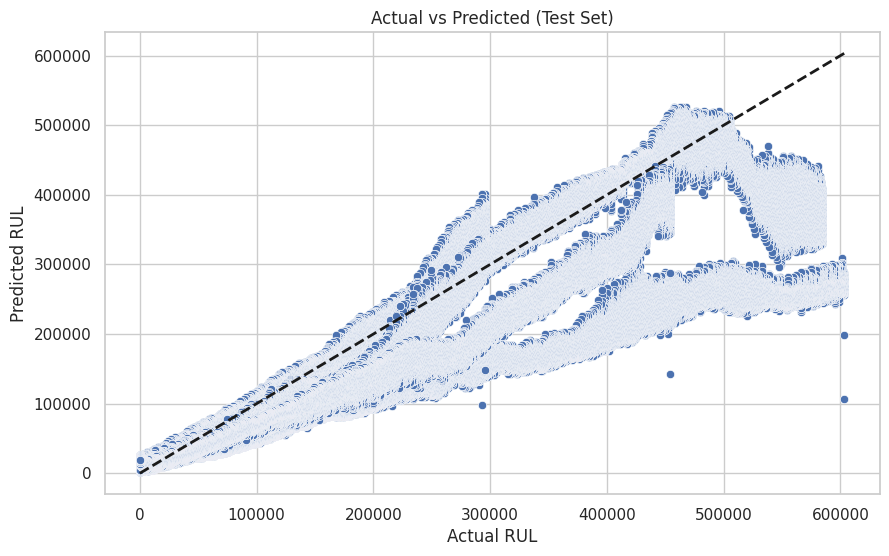

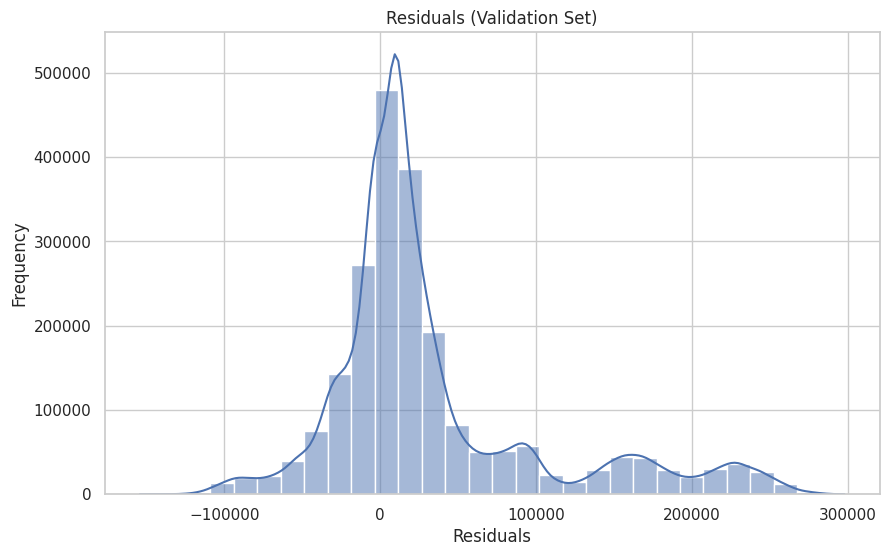

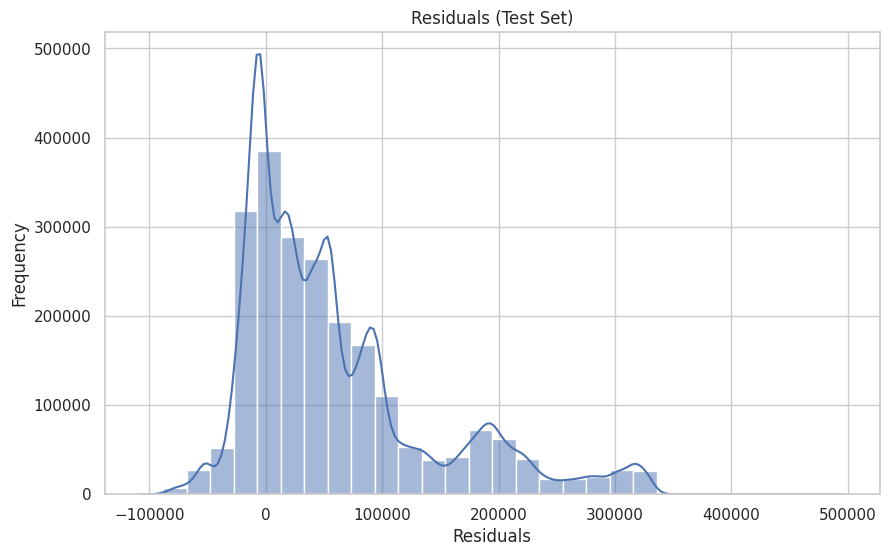

In [17]:
# 7A/ VISUALIZATION - Predictions vs True RUL

print_header("7A/ VISUALIZATION - Predictions vs True RUL")

# Function to plot feature importance
def plot_feature_importance(model, features):
    plt.figure(figsize=(10, 8))
    sns.barplot(x=model.feature_importances_, y=features)
    plt.title('Feature Importances')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.show()

# Function to plot actual vs predicted values
def plot_actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_true, y=y_pred)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    plt.title(title)
    plt.xlabel('Actual RUL')
    plt.ylabel('Predicted RUL')
    plt.show()

# Function to plot residuals
def plot_residuals(y_true, y_pred, title):
    residuals = y_true - y_pred
    plt.figure(figsize=(10, 6))
    sns.histplot(residuals, bins=30, kde=True)
    plt.title(title)
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.show()

# Plot feature importances
plot_feature_importance(base_model, selected_features)

# Plot actual vs predicted values for validation set
plot_actual_vs_predicted(y_val_long, y_val_pred, 'Actual vs Predicted (Validation Set)')

# Plot actual vs predicted values for test set
plot_actual_vs_predicted(y_test_long, y_test_pred, 'Actual vs Predicted (Test Set)')

# Plot residuals for validation set
plot_residuals(y_val_long, y_val_pred, 'Residuals (Validation Set)')

# Plot residuals for test set
plot_residuals(y_test_long, y_test_pred, 'Residuals (Test Set)')

## 8) Two Stage Models

### 8.1) STAGE 1 - Critical Region Classification

In [18]:
# 8/ GATEKEEPER MODEL

# STAGE 1 Critical Region Classification Hydraulic Press

# Preconditions
assert 'X_train_short' in globals() and 'y_train_short' in globals()
assert 'X_val_short' in globals() and 'y_val_short' in globals()
assert 'X_test_short' in globals() and 'y_test_short' in globals()
assert 'selected_features' in globals()

print_header("STAGE 1 - Critical Region Detector - HYDRAULIC PRESS")

# Binary target
CRITICAL_LIMIT = 100

y_train_critical = (y_train_short <= CRITICAL_LIMIT).astype(int)
y_val_critical   = (y_val_short   <= CRITICAL_LIMIT).astype(int)
y_test_critical  = (y_test_short  <= CRITICAL_LIMIT).astype(int)

print("Critical ratio:")
print(f"Train: {y_train_critical.mean() * 100:.2f}%")
print(f"Val  : {y_val_critical.mean() * 100:.2f}%")
print(f"Test : {y_test_critical.mean() * 100:.2f}%")

# Compute scale_pos_weight
negative_count, positive_count = np.bincount(y_train_critical)
scale_pos_weight = negative_count / positive_count

print(f"scale_pos_weight = {scale_pos_weight:.1f}")

stage1_classifier = XGBClassifier(
                                    n_estimators=400,
                                    max_depth=4,
                                    learning_rate=0.05,
                                    subsample=0.8,
                                    colsample_bytree=0.8,
                                    min_child_weight=5,
                                    gamma=0.2,
                                    scale_pos_weight=scale_pos_weight,
                                    objective="binary:logistic",
                                    eval_metric="logloss",
                                    random_state=42,
                                    n_jobs=-1,
                                    tree_method="hist"
                                )

stage1_classifier.fit(
                        X_train_short,
                        y_train_critical,
                        eval_set=[(X_val_short, y_val_critical)],
                        early_stopping_rounds=50,
                        verbose=50
                    )

# Predict probabilities
val_probabilities = stage1_classifier.predict_proba(X_val_short)[:, 1]

# Dual threshold gate hysteresis
THRESH_ENTER = 0.6
THRESH_EXIT  = 0.2

# Calibration aware tri state decision
val_prediction = np.zeros_like(val_probabilities, dtype=int)

val_prediction[val_probabilities >= THRESH_ENTER] = 1
val_prediction[val_probabilities <= THRESH_EXIT]  = 0
val_prediction[
                (val_probabilities > THRESH_EXIT) &
                (val_probabilities < THRESH_ENTER)
              ] = -1

print("\nVALIDATION PERFORMANCE Dual Threshold")
print("Confusion Matrix Critical vs Non Critical only:")
known_mask = val_prediction != -1
print(confusion_matrix(y_val_critical[known_mask], val_prediction[known_mask]))
print(classification_report(y_val_critical[known_mask], val_prediction[known_mask], digits=3))

test_probabilities = stage1_classifier.predict_proba(X_test_short)[:, 1]

test_prediction = np.zeros_like(test_probabilities, dtype=int)
test_prediction[test_probabilities >= THRESH_ENTER] = 1
test_prediction[test_probabilities <= THRESH_EXIT]  = 0

test_prediction[
                (test_probabilities > THRESH_EXIT) &
                (test_probabilities < THRESH_ENTER)
              ] = -1

print("\nTEST PERFORMANCE Dual Threshold")
known_mask = test_prediction != -1
print(confusion_matrix(y_test_critical[known_mask], test_prediction[known_mask]))
print(classification_report(y_test_critical[known_mask], test_prediction[known_mask], digits=3))

# Diagnostics uncertainty rate
uncertain_rate_percent = (test_prediction == -1).mean() * 100
print(f"\nUNCERTAIN samples in TEST: {uncertain_rate_percent:.2f}%")

# Save model
stage1_classifier.save_model(f"{save_path}hydraulic_press_stage1_classifier.json")
print(f"Model saved: {save_path}hydraulic_press_stage1_classifier.json")

print_footer("STAGE 1 COMPLETE")



STAGE 1 - Critical Region Detector - HYDRAULIC PRESS
Critical ratio:
Train: 5.46%
Val  : 4.95%
Test : 5.39%
scale_pos_weight = 17.3
[0]	validation_0-logloss:0.65661
[50]	validation_0-logloss:0.19078
[100]	validation_0-logloss:0.16615
[150]	validation_0-logloss:0.15477
[200]	validation_0-logloss:0.15279
[231]	validation_0-logloss:0.15336

VALIDATION PERFORMANCE Dual Threshold
Confusion Matrix Critical vs Non Critical only:
[[22934  1316]
 [   49  1093]]
              precision    recall  f1-score   support

           0      0.998     0.946     0.971     24250
           1      0.454     0.957     0.616      1142

    accuracy                          0.946     25392
   macro avg      0.726     0.951     0.793     25392
weighted avg      0.973     0.946     0.955     25392


TEST PERFORMANCE Dual Threshold
[[20798  1260]
 [    6  1211]]
              precision    recall  f1-score   support

           0      1.000     0.943     0.970     22058
           1      0.490     0.995     0.65

### 8.2) STAGE 2A - Critical Regression

In [21]:
# 8A/ STAGE 2A - Critical Regressor (RUL <= 50) - HYDRAULIC PRESS
print_header("8A/ STAGE 2A - Critical Region Regressor (RUL <= 50) - HYDRAULIC PRESS")

# Preconditions
assert 'X_train_short' in globals() and 'y_train_short' in globals()
assert 'X_val_short' in globals() and 'y_val_short' in globals()
assert 'X_test_short' in globals() and 'y_test_short' in globals()
assert 'selected_features' in globals()

# Select critical samples
CRITICAL_MAX_RUL = 50

train_mask = y_train_short <= CRITICAL_MAX_RUL
val_mask   = y_val_short   <= CRITICAL_MAX_RUL
test_mask  = y_test_short  <= CRITICAL_MAX_RUL

X_train_critical = X_train_short.loc[train_mask, selected_features]
y_train_critical = y_train_short.loc[train_mask]

X_val_critical = X_val_short.loc[val_mask, selected_features]
y_val_critical = y_val_short.loc[val_mask]

X_test_critical = X_test_short.loc[test_mask, selected_features]
y_test_critical = y_test_short.loc[test_mask]

print(f"Critical samples:")
print(f"  Train: {len(X_train_critical)}")
print(f"    Val: {len(X_val_critical)}")
print(f"   Test: {len(X_test_critical)}")

assert len(X_train_critical) > 0, "No critical training samples"

# Aggressive weighting for imminent failure
sample_weights_critical = np.ones_like(y_train_critical, dtype=float)
sample_weights_critical[y_train_critical <= 30] = 2.0
sample_weights_critical[y_train_critical <= 15] = 4.0
sample_weights_critical[y_train_critical <= 7]  = 8.0

# Model optimized for local accuracy in critical region
stage2a_regressor = XGBRegressor(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.03,
    min_child_weight=1,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.0,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

stage2a_regressor.fit(
    X_train_critical,
    y_train_critical,
    sample_weight=sample_weights_critical,
    eval_set=[(X_val_critical, y_val_critical)],
    eval_metric="mae",
    early_stopping_rounds=80,
    verbose=50
)

print(f"\nBest iteration: {stage2a_regressor.best_iteration}")

# Evaluation
y_val_pred_critical  = stage2a_regressor.predict(X_val_critical)
y_test_pred_critical = stage2a_regressor.predict(X_test_critical)

val_mae_critical  = MAE(y_val_critical, y_val_pred_critical)
test_mae_critical = MAE(y_test_critical, y_test_pred_critical)

val_accuracy_10min  = (np.abs(y_val_critical - y_val_pred_critical) <= 10).mean() * 100
test_accuracy_10min = (np.abs(y_test_critical - y_test_pred_critical) <= 10).mean() * 100

print("\nCRITICAL REGRESSOR PERFORMANCE:")
print(f"Validation - MAE: {val_mae_critical:.2f}, +/-10min: {val_accuracy_10min:.1f}%")
print(f"      Test - MAE: {test_mae_critical:.2f}, +/-10min: {test_accuracy_10min:.1f}%")

# save model
stage2a_regressor.save_model(f"{save_path}hydraulic_press_stage2a_regressor.json")
print(f"Model saved: {save_path}hydraulic_press_stage2a_regressor.json")

print_footer("STAGE 2A COMPLETE")



8A/ STAGE 2A - Critical Region Regressor (RUL <= 50) - HYDRAULIC PRESS
Critical samples:
  Train: 2754
    Val: 663
   Test: 663
[0]	validation_0-mae:14.97973
[50]	validation_0-mae:14.28532
[100]	validation_0-mae:13.64416
[150]	validation_0-mae:13.26586
[200]	validation_0-mae:13.08572
[250]	validation_0-mae:12.96999
[300]	validation_0-mae:12.97144
[337]	validation_0-mae:12.92863

Best iteration: 258

CRITICAL REGRESSOR PERFORMANCE:
Validation - MAE: 12.91, +/-10min: 45.4%
      Test - MAE: 13.86, +/-10min: 40.1%
Model saved: models_and_features/hydraulic_press/hydraulic_press_stage2a_regressor.json

----------------------------------------------------------------------
STAGE 2A COMPLETE
----------------------------------------------------------------------


## 9) Two Stage Inference & Evaluation

In [22]:
# 9/ FINAL TWO-STAGE INFERENCE & EVALUATION (Production-Ready Routing)
print_header("9/ FINAL TWO-STAGE INFERENCE - PRODUCTION PIPELINE")

# Preconditions
assert 'base_model' in globals(), "Base regressor not found"
assert 'stage1_classifier' in globals(), "Stage-1 classifier not found"
assert 'stage2a_regressor' in globals(), "Stage-2A regressor not found"


X_eval = X_test_long
y_eval = y_test_long

# STAGE-1 CRITICAL DETECTION (RUL <= 100)
print("\n[Stage 1] Critical region detection...")

critical_prob = stage1_classifier.predict_proba(X_eval)[:, 1]

THRESH_ENTER = 0.6
THRESH_EXIT  = 0.2

critical_flag = np.zeros_like(critical_prob, dtype=int)
critical_flag[critical_prob >= THRESH_ENTER] = 1
critical_flag[critical_prob <= THRESH_EXIT]  = 0
critical_flag[
                (critical_prob > THRESH_EXIT) & 
                (critical_prob < THRESH_ENTER)
            ] = -1   # UNCERTAIN


print(f"\nDetected critical samples: {critical_flag.sum()} / {len(critical_flag)}")

# BASE PREDICTION (DEFAULT)
final_pred = base_model.predict(X_eval)


# STAGE-2A (RUL <= 100)
print("\n[Stage 2A] Applying critical regressor (RUL <= 100)...")

# Do not override uncertain samples
uncertain_mask = critical_flag == -1
idx_critical = np.where(critical_flag == 1)[0]


if len(idx_critical) > 0:
    X_crit = X_eval.iloc[idx_critical]
    pred_2a = stage2a_regressor.predict(X_crit)

    final_pred[idx_critical] = pred_2a


# Safety clip
final_pred = np.clip(final_pred, 0, 48000)

print(f"Stage-2A used on {len(idx_critical)} samples")

# FINAL EVALUATION
print("\n=== FINAL SYSTEM PERFORMANCE (TEST SET) ===")

final_mae = MAE(y_eval, final_pred)
final_rmse = R_MSE(y_eval, final_pred)
final_r2 = r2_score(y_eval, final_pred)

print(f" MAE: {final_mae:.2f}")
print(f"RMSE: {final_rmse:.2f}")
print(f" R^2: {final_r2*100:.2f}% ({final_r2:.4f})")


# CRITICAL REGION METRICS
print("\n=== FINAL CRITICAL REGION (RUL <= 20) ===")

crit_mask = y_eval <= 20
n_crit = crit_mask.sum()

if n_crit > 0:
    crit_mae = MAE(y_eval[crit_mask], final_pred[crit_mask])
    crit_acc10 = (np.abs(y_eval[crit_mask] - final_pred[crit_mask]) <= 10).mean() * 100

    print(f"      Samples: {n_crit}")
    print(f"          MAE: {crit_mae:.2f}")
    print(f"    +/-10 min: {crit_acc10:.1f}%")
else:
    crit_acc10 = None
    print("No critical samples")

print_footer("FINAL TWO-STAGE PIPELINE COMPLETE")



9/ FINAL TWO-STAGE INFERENCE - PRODUCTION PIPELINE

[Stage 1] Critical region detection...

Detected critical samples: -12788 / 2230941

[Stage 2A] Applying critical regressor (RUL <= 100)...
Stage-2A used on 1667 samples

=== FINAL SYSTEM PERFORMANCE (TEST SET) ===
 MAE: 199084.85
RMSE: 251335.83
 R^2: -151.62% (-1.5162)

=== FINAL CRITICAL REGION (RUL <= 20) ===
      Samples: 105
          MAE: 11.68
    +/-10 min: 43.8%

----------------------------------------------------------------------
FINAL TWO-STAGE PIPELINE COMPLETE
----------------------------------------------------------------------


## 10) Sanity Checks

In [23]:
# 10/ SANITY CHECKS - Two-Stage RUL System (Correct & Defensible)
print_header("10/ SANITY CHECKS - Two-Stage RUL System (Correct Evaluation)")

# Preconditions
assert 'base_model' in globals(), "Base regressor missing"
assert 'stage1_classifier' in globals(), "Stage-1 classifier missing"
assert 'stage2a_regressor' in globals(), "Stage-2A regressor missing"


# STAGE-1 CLASSIFIER SANITY CHECK
print("\n=== STAGE 1: CRITICAL REGION DETECTOR (Trigger RUL <= 100) ===")

# Stage-1 artık 100 dakika eşiğinde çalışıyor (Routing'de kullandığımız veri seti)
y_test_crit_true = (y_test_long <= 100).astype(int)
y_test_crit_prob = stage1_classifier.predict_proba(X_test_long)[:, 1]

THRESH_ENTER = 0.6
THRESH_EXIT  = 0.2

y_test_crit_pred = np.zeros_like(y_test_crit_prob, dtype=int)
y_test_crit_pred[y_test_crit_prob >= THRESH_ENTER] = 1
y_test_crit_pred[y_test_crit_prob <= THRESH_EXIT]  = 0

# UNCERTAIN samples are excluded from sanity metrics
known_mask = (y_test_crit_prob >= THRESH_ENTER) | (y_test_crit_prob <= THRESH_EXIT)

tp = ((y_test_crit_pred == 1) & (y_test_crit_true == 1) & known_mask).sum()
fn = ((y_test_crit_pred == 0) & (y_test_crit_true == 1) & known_mask).sum()
fp = ((y_test_crit_pred == 1) & (y_test_crit_true == 0) & known_mask).sum()


recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
fnr = fn / (tp + fn) if (tp + fn) > 0 else 0.0

print(f"Critical recall         : {recall:.3f}")
print(f"Critical precision      : {precision:.3f}")
print(f"False negative rate     : {fnr:.3f}")

stage1_pass = recall >= 0.85 # We expect higher recall for Stage-1
print(f"Stage-1 verdict         : {'PASS' if stage1_pass else 'FAIL'}")


# STAGE-2A CRITICAL REGRESSOR SANITY CHECK
print("\n=== STAGE 2A: CRITICAL REGRESSOR (RUL <= 100) ===")

mask_100 = y_test_long <= 100
X_test_100 = X_test_long[mask_100]
y_test_100 = y_test_long[mask_100]

y_pred_100 = stage2a_regressor.predict(X_test_100)
mae_100 = MAE(y_test_100, y_pred_100)

print(f"           Samples: {len(y_test_100)}")
print(f"       MAE (<=100): {mae_100:.2f}")
stage2a_pass = mae_100 <= 30 # MAE is naturally higher for 100min range
print(f"  Stage-2A verdict: {'PASS' if stage2a_pass else 'FAIL'}")


# FINAL TWO-STAGE SYSTEM (CRITICAL-FOCUSED)
print("\n=== FINAL TWO-STAGE SYSTEM (CRITICAL FOCUS) ===")

# final_pred was computed on X_test_long in Step 9
assert 'final_pred' in globals(), "final_pred not found from #9"

mask_20 = y_test_long <= 20
y_test_20 = y_test_long[mask_20]

final_mae_20 = MAE(y_test_20, final_pred[mask_20])
final_acc10_20 = (np.abs(y_test_20 - final_pred[mask_20]) <= 10).mean() * 100

print(f"        Final MAE (<=20): {final_mae_20:.2f}")
print(f"Final +/-10 min accuracy: {final_acc10_20:.1f}%")

final_system_pass = final_acc10_20 >= 60 # Project goal is 60%
print(f"    Final system verdict: {'PASS' if final_system_pass else 'FAIL'}")


# BASE MODEL DRIFT CHECK (DIAGNOSTIC ONLY)
print("\n=== DRIFT CHECK (BASE MODEL - DIAGNOSTIC) ===")

ks_p_values = []
# Using long-life sets for global comparison
for col in X_train_long.columns:
    _, p = ks_2samp(X_train_long[col], X_test_long[col])
    ks_p_values.append(p)

feature_drift_ratio = np.mean(np.array(ks_p_values) < 0.05)
_, target_p = ks_2samp(y_train_long, y_test_long)

print(f"Feature drift ratio: {feature_drift_ratio:.2f}")
print(f"  Target KS p-value: {target_p:.4f}")

print("Drift interpretation: Expected (domain + degradation shift)")


# FINAL SANITY SUMMARY
print("\n=== FINAL SANITY SUMMARY ===")
print(f"Stage-1 classifier     : {'PASS' if stage1_pass else 'FAIL'}")
print(f"Stage-2A regressor     : {'PASS' if stage2a_pass else 'FAIL'}")
print(f"Two-stage system       : {'PASS' if final_system_pass else 'FAIL'}")

print_footer("SANITY CHECKS COMPLETE")


10/ SANITY CHECKS - Two-Stage RUL System (Correct Evaluation)

=== STAGE 1: CRITICAL REGION DETECTOR (Trigger RUL <= 100) ===
Critical recall         : 1.000
Critical precision      : 0.284
False negative rate     : 0.000
Stage-1 verdict         : PASS

=== STAGE 2A: CRITICAL REGRESSOR (RUL <= 100) ===
           Samples: 505
       MAE (<=100): 33.34
  Stage-2A verdict: FAIL

=== FINAL TWO-STAGE SYSTEM (CRITICAL FOCUS) ===
        Final MAE (<=20): 11.68
Final +/-10 min accuracy: 43.8%
    Final system verdict: FAIL

=== DRIFT CHECK (BASE MODEL - DIAGNOSTIC) ===
Feature drift ratio: 1.00
  Target KS p-value: 0.0000
Drift interpretation: Expected (domain + degradation shift)

=== FINAL SANITY SUMMARY ===
Stage-1 classifier     : PASS
Stage-2A regressor     : FAIL
Two-stage system       : FAIL

----------------------------------------------------------------------
SANITY CHECKS COMPLETE
----------------------------------------------------------------------



10A/ VISUALIZATION - Two-Stage RUL System Predictions vs True RUL


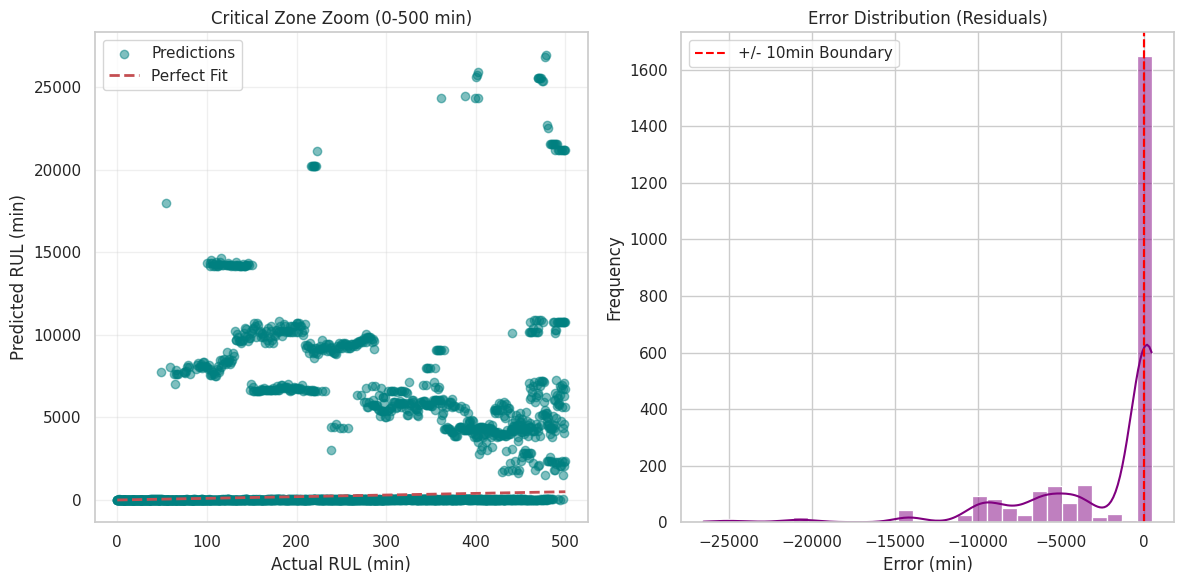

In [24]:
# 10A/ VISUALIZATION - Two-Stage RUL System Predictions vs True RUL
print_header("10A/ VISUALIZATION - Two-Stage RUL System Predictions vs True RUL")

# Visualization: Predicted vs Actual (Zoomed to 0-500 Range)
plt.figure(figsize=(12, 6))

# Filter samples for a clearer view
mask_zoom = y_eval <= 500
y_true_zoom = y_eval[mask_zoom]
y_pred_zoom = final_pred[mask_zoom]

plt.subplot(1, 2, 1)
plt.scatter(y_true_zoom, y_pred_zoom, alpha=0.5, color='teal', label='Predictions')
plt.plot([0, 500], [0, 500], 'r--', lw=2, label='Perfect Fit')
plt.title("Critical Zone Zoom (0-500 min)")
plt.xlabel("Actual RUL (min)")
plt.ylabel("Predicted RUL (min)")
plt.legend()
plt.grid(True, alpha=0.3)

# Visualization: Error Distribution (The Residuals)
plt.subplot(1, 2, 2)
residuals = y_true_zoom - y_pred_zoom
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.axvline(x=10, color='red', linestyle='--', label='+/- 10min Boundary')
plt.axvline(x=-10, color='red', linestyle='--')
plt.title("Error Distribution (Residuals)")
plt.xlabel("Error (min)")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

## 11) Save as ONNX

In [ ]:
# 11 / Save models as ONNX

print_header("11/ SAVE MODELS AS ONNX FORMAT")

# BASE MODEL

# Fix feature names inside booster for ONNX compatibility
booster = base_model.get_booster()
booster.feature_names = [f"f{i}" for i in range(len(booster.feature_names))]

n_features = X_train_long.shape[1]

# ONNX input type
initial_type = [('input', FloatTensorType([None, n_features]))]

# XGBoost -> ONNX
onnx_model = onnxmltools.convert_xgboost(
                                            model=base_model,
                                            initial_types=initial_type
                                        )

# Save ONNX file
onnx_path = f"{save_path}process_pump_base_model.onnx"
with open(onnx_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"\nBASE MODEL is converted to ONNX and saved to: {onnx_path}")

# STG1 CLASSIFIER

# Fix feature names inside booster for ONNX compatibility
booster = stage1_classifier.get_booster()
booster.feature_names = [f"f{i}" for i in range(len(booster.feature_names))]

n_features = X_train_short.shape[1]

# ONNX input type
initial_type = [('input', FloatTensorType([None, n_features]))]

# XGBoost -> ONNX
onnx_model = onnxmltools.convert_xgboost(
                                            model=stage1_classifier,
                                            initial_types=initial_type
                                        )

# Save ONNX file
onnx_path = f"{save_path}process_pump_stage1_classifier.onnx"
with open(onnx_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"\nSTG1 CLASSIFIER is converted to ONNX and saved to: {onnx_path}")


# STG2A REGRESSOR 

# Fix feature names inside booster for ONNX compatibility
booster = stage2a_regressor.get_booster()
booster.feature_names = [f"f{i}" for i in range(len(booster.feature_names))]

n_features = X_train_c.shape[1]

# ONNX input type
initial_type = [('input', FloatTensorType([None, n_features]))]

# XGBoost -> ONNX
onnx_model = onnxmltools.convert_xgboost(
                                            model=stage2a_regressor,
                                            initial_types=initial_type
                                        )

# Save ONNX file
onnx_path = f"{save_path}process_pump_stage2a_regressor.onnx"
with open(onnx_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"\nSTG2A REGRESSOR is converted to ONNX and saved to: {onnx_path}")



# Save ONNX file
onnx_path = f"{save_path}process_pump_stage2b_regressor.onnx"
with open(onnx_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"\nSTG2B REGRESSOR is converted to ONNX and saved to: {onnx_path}")

print_footer("ALL MODELS SAVED AS ONNX")
